# set-Up

In [1]:
import sys

assert sys.version_info >= (3, 7)

In [2]:
from packaging import version
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [4]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "deep"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [5]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]
X_train, X_valid, X_test = X_train / 255, X_valid / 255, X_test / 255

In [6]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# The Vanishing/Exploding Gradients Problems

* Backpropagation works by propagating the **error gradient from output layer → input layer**, then updating parameters using gradient descent

* Deep neural networks often suffer from **unstable gradients**:

  * Gradients can **shrink → vanishing gradients**
  * Gradients can **grow → exploding gradients**

* **Vanishing gradients problem**:

  * Gradients become extremely small in lower layers
  * Weight updates ≈ 0 → lower layers stop learning
  * Training fails to converge properly

* **Exploding gradients problem**:

  * Gradients become very large
  * Causes huge weight updates
  * Training becomes unstable and may diverge
  * More common in **Recurrent Neural Networks (RNNs)**

* Different layers in deep networks may **learn at different speeds** due to unstable gradients

* This issue was a major reason why **deep neural networks were abandoned (early 2000s)**

* Key causes identified (Glorot & Bengio, 2010):

  * Use of **sigmoid activation function**
  * Poor **weight initialization** (normal distribution with mean = 0, std = 1)

* Problem with sigmoid + bad initialization:

  * Output variance increases layer by layer
  * Leads to **activation saturation in deeper layers**

* **Sigmoid activation function**:

  * Range:
    σ(x) = 1 / (1 + e^(-x))
  * Mean ≈ 0.5 (not centered at 0 → causes issues)

* **Saturation issue**:

  * For large positive or negative inputs:

    * Output ≈ 1 or 0
    * Derivative ≈ 0
  * Result:

    * Gradient ≈ 0 during backpropagation
    * Learning slows down or stops

* During backpropagation:

  * Small gradients get **progressively weaker** as they move backward
  * By the time they reach lower layers → **almost zero information remains**

* **tanh activation** performs slightly better than sigmoid:

  * Mean = 0 (centered)
  * Reduces but does not fully solve the problem


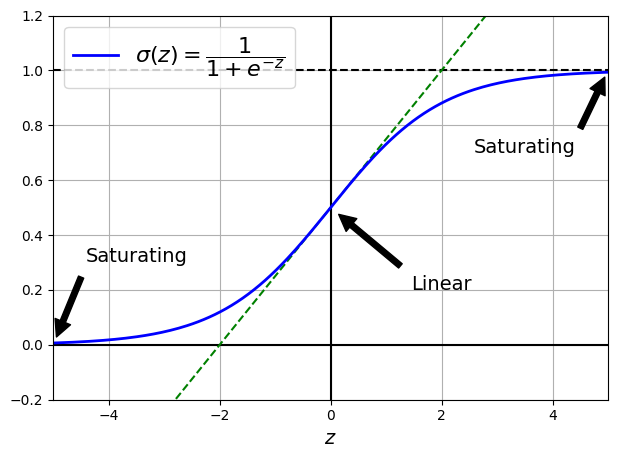

In [5]:
# extra code – this cell generates and saves Figure 11–1

import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-5, 5, 200)

plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [1, 1], 'k--')
plt.plot([0, 0], [-0.2, 1.2], 'k-')
plt.plot([-5, 5], [-3/4, 7/4], 'g--')
plt.plot(z, sigmoid(z), "b-", linewidth=2,
         label=r"$\sigma(z) = \dfrac{1}{1+e^{-z}}$")
props = dict(facecolor='black', shrink=0.1)
plt.annotate('Saturating', xytext=(3.5, 0.7), xy=(5, 1), arrowprops=props,
             fontsize=14, ha="center")
plt.annotate('Saturating', xytext=(-3.5, 0.3), xy=(-5, 0), arrowprops=props,
             fontsize=14, ha="center")
plt.annotate('Linear', xytext=(2, 0.2), xy=(0, 0.5), arrowprops=props,
             fontsize=14, ha="center")
plt.grid(True)
plt.axis([-5, 5, -0.2, 1.2])
plt.xlabel("$z$")
plt.legend(loc="upper left", fontsize=16)

save_fig("sigmoid_saturation_plot")
plt.show()

## Glorot and He Initialization

* Goal: ensure **stable signal flow** in both directions:

  * Forward pass → predictions
  * Backward pass → gradients
  * Avoid **vanishing (signal dies)** and **exploding (signal blows up)**

* Key requirement for stability:

  * Variance of outputs ≈ variance of inputs
  * Gradient variance before and after a layer should remain similar

* Definitions:

  * **fan_in** = number of input connections to a layer
  * **fan_out** = number of output connections from a layer
  * **fan_avg** = (fan_in + fan_out) / 2

* Perfect stability (same variance forward & backward) is only possible if:

  * fan_in = fan_out
  * Otherwise → need a compromise

* **Glorot (Xavier) Initialization**:

  * Designed to maintain stable variance across layers

  * Works well for **sigmoid, tanh, softmax**

  * Normal distribution:
    W ~ N(0, σ²), where
    σ² = 1 / fan_avg

  * Uniform distribution:
    W ~ U(-r, r), where
    r = sqrt(3 / fan_avg)

* **LeCun Initialization**:

  * Uses fan_in instead of fan_avg
  * Formula:
    σ² = 1 / fan_in
  * Equivalent to Glorot when fan_in = fan_out

* **He (Kaiming) Initialization**:

  * Designed for **ReLU and its variants**

  * Helps avoid vanishing gradients in ReLU networks

  * Formula:
    σ² = 2 / fan_in

* Summary of initialization strategies:

  * Glorot → sigmoid, tanh, softmax → σ² = 1 / fan_avg
  * He → ReLU, Leaky ReLU, ELU, GELU, Swish, Mish → σ² = 2 / fan_in
  * LeCun → SELU → σ² = 1 / fan_in

* Insight:

  * Different activation functions require **different scaling of weights**
  * Proper initialization → **faster training + stable gradients**

* In practice (TensorFlow/Keras):

  * Default = Glorot initialization

  * Example (He initialization):
    dense = tf.keras.layers.Dense(50, activation="relu",
    kernel_initializer="he_normal")

* Custom initialization using VarianceScaling:

  * Allows control over:

    * scale (variance factor)
    * mode (fan_in, fan_out, fan_avg)
    * distribution (normal or uniform)

  * Example:
    he_avg_init = tf.keras.initializers.VarianceScaling(
    scale=2., mode="fan_avg", distribution="uniform"
    )

    dense = tf.keras.layers.Dense(50, activation="sigmoid",
    kernel_initializer=he_avg_init)

* Key takeaway:

  * Proper weight initialization is **critical for deep learning success**
  * It directly affects:

    * gradient flow
    * training speed
    * model convergence 🚀


In [6]:
dense = tf.keras.layers.Dense(50, activation="relu",
                              kernel_initializer="he_normal")

In [7]:
he_avg_init = tf.keras.initializers.VarianceScaling(scale=2., mode="fan_avg",
                                                    distribution="uniform")
dense = tf.keras.layers.Dense(50, activation="sigmoid",
                              kernel_initializer=he_avg_init)

## Better Activation Functions

* Key insight: **activation function choice strongly affects gradient stability**

* Earlier assumption:

  * Sigmoid was widely used because it resembles **biological neurons**
  * But in deep networks → performs poorly

* **ReLU (Rectified Linear Unit)** became preferred:

  * Does **not saturate for positive values**
  * Faster to compute than sigmoid

* ReLU function:

  * f(x) = max(0, x)

* Advantages of ReLU:

  * Reduces **vanishing gradient problem**
  * Enables **faster training**
  * Computationally efficient

* Problem with ReLU → **Dying ReLU problem**:

  * Some neurons output **only 0 for all inputs**
  * These neurons become inactive (“dead”)

* Why neurons die:

  * If input to ReLU is always negative:

    * f(x) = 0
    * Gradient = 0
  * No gradient → no weight updates → neuron never recovers

* Causes of dying ReLU:

  * **Large learning rate**
  * Poor weight updates pushing neuron into negative region

* Impact:

  * Large portion of network (sometimes ~50%) may become inactive
  * Reduces model capacity and performance

* Solution → use **ReLU variants**:

  * Example: **Leaky ReLU**

* Leaky ReLU idea:

  * Allows small gradient when x < 0
  * Instead of zero, gives small negative slope

* Leaky ReLU function:

  * f(x) = x        if x > 0
  * f(x) = αx       if x ≤ 0  (α is small, e.g., 0.01)

* Benefit:

  * Prevents neurons from dying
  * Keeps gradient flow alive even for negative inputs

* Key takeaway:

  * Activation functions are **critical for deep learning stability**
  * ReLU improved performance over sigmoid, but variants like **Leaky ReLU fix its limitations** 🚀


### Leaky ReLU

* **Leaky ReLU activation function**:

  * LeakyReLU(z) = max(αz, z)
  * α = slope for negative values (z < 0)

* Key idea:

  * Unlike ReLU, it allows a **small non-zero gradient when z < 0**
  * Prevents neurons from permanently dying

* Behavior:

  * If z > 0 → f(z) = z
  * If z < 0 → f(z) = αz

* Advantage:

  * Neurons may become inactive temporarily (“coma”) but can **recover later**

* Empirical findings (Bing Xu et al., 2015):

  * Leaky ReLU variants **outperform standard ReLU**
  * Larger α (e.g., α = 0.2) performed better than small α (e.g., α = 0.01)

* Variants of Leaky ReLU:

  * **Randomized Leaky ReLU (RReLU)**:

    * α is randomly sampled during training
    * Fixed to average value during testing
    * Acts as a **regularizer → reduces overfitting**

  * **Parametric ReLU (PReLU)**:

    * α is **learned during training** (not fixed)
    * Becomes a trainable parameter updated via backpropagation
    * Performs well on **large datasets**
    * Risk: may **overfit on small datasets**

* Implementation notes (Keras):

  * Available layers:

    * LeakyReLU
    * PReLU
  * Can be used:

    * As activation function
    * Or as a separate layer (same effect)

* Initialization:

  * Use **He initialization** with ReLU variants for best performance

* Limitation of ReLU family (ReLU, Leaky ReLU, PReLU):

  * **Not smooth functions**
  * Derivative is discontinuous at z = 0

* Impact of non-smoothness:

  * Gradient descent may:

    * **Oscillate near optimum**
    * Converge more slowly

* Motivation for next step:

  * Use **smooth activation functions** (e.g., ELU, SELU)
  * Aim: better convergence and stability 🚀


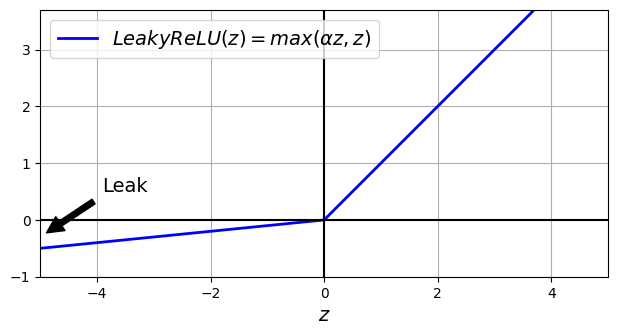

In [8]:
# extra code – this cell generates and saves Figure 11–2

def leaky_relu(z, alpha):
    return np.maximum(alpha * z, z)

z = np.linspace(-5, 5, 200)
plt.plot(z, leaky_relu(z, 0.1), "b-", linewidth=2, label=r"$LeakyReLU(z) = max(\alpha z, z)$")
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([0, 0], [-1, 3.7], 'k-')
plt.grid(True)
props = dict(facecolor='black', shrink=0.1)
plt.annotate('Leak', xytext=(-3.5, 0.5), xy=(-5, -0.3), arrowprops=props,
             fontsize=14, ha="center")
plt.xlabel("$z$")
plt.axis([-5, 5, -1, 3.7])
plt.gca().set_aspect("equal")
plt.legend()

save_fig("leaky_relu_plot")
plt.show()

In [10]:
leaky_relu = tf.keras.layers.LeakyReLU(negative_slope=0.2)  # defaults to alpha=0.3 alpha is replaced in newer versions
dense = tf.keras.layers.Dense(50, activation=leaky_relu,
                              kernel_initializer="he_normal")

In [11]:
model = tf.keras.models.Sequential([
    # [...]  # more layers
    tf.keras.layers.Dense(50, kernel_initializer="he_normal"),  # no activation
    tf.keras.layers.LeakyReLU(negative_slope=0.2),  # activation as a separate layer
    # [...]  # more layers
])

### ELU and SELU

In [12]:
dense = tf.keras.layers.Dense(50, activation="elu",
                              kernel_initializer="he_normal")

* **ELU (Exponential Linear Unit)** introduced to improve over ReLU variants

* ELU activation function:

  * ELU(α, z) = z                    if z ≥ 0
  * ELU(α, z) = α (e^z − 1)          if z < 0

* Key characteristics:

  * Produces **negative outputs for z < 0**

    * Helps make mean activation closer to 0
    * Reduces **vanishing gradient problem**

  * Has **non-zero gradient for z < 0**

    * Prevents **dead neurons problem** (unlike ReLU)

  * Controlled by hyperparameter **α**:

    * Defines how negative the function can go
    * Typically α = 1

* Smoothness:

  * If α = 1 → ELU is **smooth everywhere (including at z = 0)**
  * Smooth gradients → **faster and more stable convergence**
  * Avoids oscillation issues seen in non-smooth functions (ReLU family)

* Advantages over ReLU:

  * Better gradient flow
  * Faster training
  * Improved performance on test data

* Drawback:

  * **Slower computation** than ReLU

    * Due to exponential calculation (e^z)

* Trade-off:

  * Slower per computation
  * But may converge faster → overall training time can still improve

* Inference (test time):

  * ELU networks are slightly **slower than ReLU networks**

* Implementation (Keras):

  * activation = "elu"

* Initialization:

  * Use **He initialization** (same as other ReLU-based activations)

* Key takeaway:

  * ELU combines benefits of:

    * ReLU (non-saturation for positive values)
    * Leaky behavior (non-zero gradient for negative values)
    * Smoothness (better optimization) 🚀


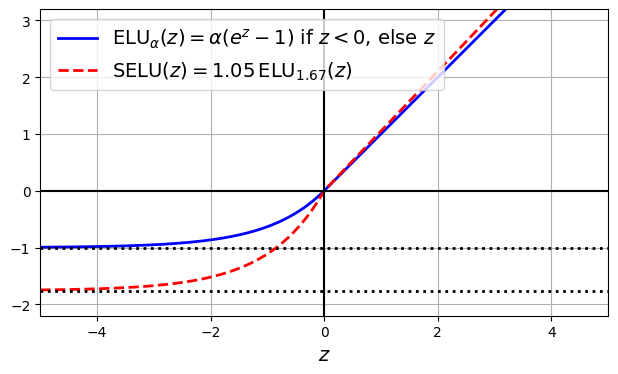

In [14]:
# extra code – this cell generates and saves Figure 11–3

from scipy.special import erfc

# alpha and scale to self normalize with mean 0 and standard deviation 1
# (see equation 14 in the paper):
alpha_0_1 = -np.sqrt(2 / np.pi) / (erfc(1 / np.sqrt(2)) * np.exp(1 / 2) - 1)
scale_0_1 = (
    (1 - erfc(1 / np.sqrt(2)) * np.sqrt(np.e))
    * np.sqrt(2 * np.pi)
    * (
        2 * erfc(np.sqrt(2)) * np.e ** 2
        + np.pi * erfc(1 / np.sqrt(2)) ** 2 * np.e
        - 2 * (2 + np.pi) * erfc(1 / np.sqrt(2)) * np.sqrt(np.e)
        + np.pi
        + 2
    ) ** (-1 / 2)
)

def elu(z, alpha=1):
    return np.where(z < 0, alpha * (np.exp(z) - 1), z)

def selu(z, scale=scale_0_1, alpha=alpha_0_1):
    return scale * elu(z, alpha)

z = np.linspace(-5, 5, 200)
plt.plot(z, elu(z), "b-", linewidth=2, label=r"ELU$_\alpha(z) = \alpha (e^z - 1)$ if $z < 0$, else $z$")
plt.plot(z, selu(z), "r--", linewidth=2, label=r"SELU$(z) = 1.05 \, $ELU$_{1.67}(z)$")
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [-1, -1], 'k:', linewidth=2)
plt.plot([-5, 5], [-1.758, -1.758], 'k:', linewidth=2)
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.axis([-5, 5, -2.2, 3.2])
plt.xlabel("$z$")
plt.gca().set_aspect("equal")
plt.legend()

save_fig("elu_selu_plot")
plt.show()

* **SELU (Scaled ELU)**:

  * Variant of ELU scaled by constants
  * Approx: SELU(z) ≈ 1.05 × ELU(z), with α ≈ 1.67

* Key property → **Self-normalization**:

  * Mean of activations → 0
  * Standard deviation → 1
  * Maintained across layers during training

* Benefit:

  * Solves **vanishing and exploding gradients**
  * Enables stable training in **deep neural networks**

* Works best for:

  * **MLPs (fully connected dense networks)**
  * Especially effective in **deep architectures**

* Conditions required for self-normalization:

  * Input data must be standardized:

    * mean = 0
    * standard deviation = 1

  * Weight initialization must be:

    * **LeCun normal initialization**
    * σ² = 1 / fan_in

  * Network architecture:

    * Only **plain MLP (no special connections)**

* Restrictions:

  * Does NOT work well with:

    * Recurrent networks
    * Networks with skip connections

  * Cannot use common regularization techniques:

    * L1 regularization
    * L2 regularization
    * Max-norm
    * Batch normalization
    * Standard dropout

* Practical impact:

  * Strong theoretical benefits
  * But **strict conditions limit real-world usage**

* In Keras:

  * activation = "selu"
  * kernel_initializer = "lecun_normal"

* Limitation:

  * Less flexible compared to other activations

* Newer activation functions outperform SELU in many tasks:

  * **GELU**
  * **Swish**
  * **Mish**

* Key takeaway:

  * SELU is powerful for **self-normalizing deep MLPs**, but its strict requirements make it less commonly used in modern architectures 🚀


In [15]:
dense = tf.keras.layers.Dense(50, activation="selu",
                              kernel_initializer="lecun_normal")

In [17]:
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[28, 28]))
for layer in range(100):
    model.add(tf.keras.layers.Dense(100, activation="selu",
                                    kernel_initializer="lecun_normal"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

C:\Users\roush\ml_env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
              metrics=["accuracy"])

In [19]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]
X_train, X_valid, X_test = X_train / 255, X_valid / 255, X_test / 255

In [20]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [22]:
# fashion_mnist

In [23]:
pixel_means = X_train.mean(axis=0, keepdims=True)
pixel_stds = X_train.std(axis=0, keepdims=True)
X_train_scaled = (X_train - pixel_means) / pixel_stds
X_valid_scaled = (X_valid - pixel_means) / pixel_stds
X_test_scaled = (X_test - pixel_means) / pixel_stds

In [24]:
history = model.fit(X_train_scaled, y_train, epochs=5,
                    validation_data=(X_valid_scaled, y_valid))

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 51s 24ms/step - accuracy: 0.5962 - loss: 1.0983 - val_accuracy: 0.7590 - val_loss: 0.6864
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 81s 23ms/step - accuracy: 0.7436 - loss: 0.7311 - val_accuracy: 0.7804 - val_loss: 0.6389
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 42s 24ms/step - accuracy: 0.7907 - loss: 0.6021 - val_accuracy: 0.8096 - val_loss: 0.5443
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 80s 23ms/step - accuracy: 0.8164 - loss: 0.5297 - val_accuracy: 0.8162 - val_loss: 0.5392
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.8295 - loss: 0.4907 - val_accuracy: 0.8292 - val_loss: 0.4881


lets look for now what a normal relu gonna do or will do in such case

In [25]:
tf.random.set_seed(42)

In [26]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[28, 28]))
for layer in range(100):
    model.add(tf.keras.layers.Dense(100, activation="relu",
                                    kernel_initializer="he_normal"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

C:\Users\roush\ml_env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
              metrics=["accuracy"])

In [28]:
history = model.fit(X_train_scaled, y_train, epochs=5,
                    validation_data=(X_valid_scaled, y_valid))

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 45s 21ms/step - accuracy: 0.2164 - loss: 2.0836 - val_accuracy: 0.2792 - val_loss: 1.9238
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - accuracy: 0.3678 - loss: 1.7007 - val_accuracy: 0.3594 - val_loss: 1.5018
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.5100 - loss: 1.1711 - val_accuracy: 0.5698 - val_loss: 1.1844
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 42s 21ms/step - accuracy: 0.6395 - loss: 0.8984 - val_accuracy: 0.7084 - val_loss: 0.7553
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accuracy: 0.6798 - loss: 0.8027 - val_accuracy: 0.7152 - val_loss: 0.7206


### GELU, Swish, and Mish

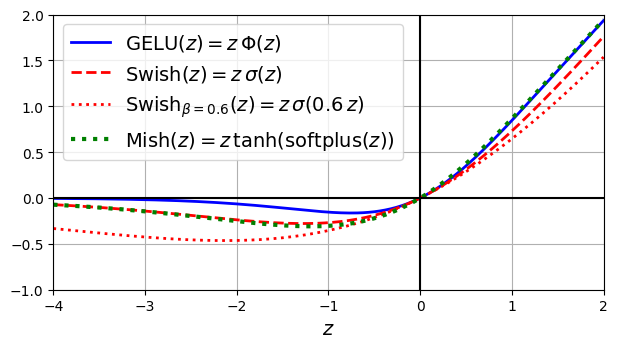

In [29]:
# extra code – this cell generates and saves Figure 11–4

def swish(z, beta=1):
    return z * sigmoid(beta * z)

def approx_gelu(z):
    return swish(z, beta=1.702)

def softplus(z):
    return np.log(1 + np.exp(z))

def mish(z):
    return z * np.tanh(softplus(z))

z = np.linspace(-4, 2, 200)

beta = 0.6
plt.plot(z, approx_gelu(z), "b-", linewidth=2,
         label=r"GELU$(z) = z\,\Phi(z)$")
plt.plot(z, swish(z), "r--", linewidth=2,
         label=r"Swish$(z) = z\,\sigma(z)$")
plt.plot(z, swish(z, beta), "r:", linewidth=2,
         label=fr"Swish$_{{\beta={beta}}}(z)=z\,\sigma({beta}\,z)$")
plt.plot(z, mish(z), "g:", linewidth=3,
         label=fr"Mish$(z) = z\,\tanh($softplus$(z))$")
plt.plot([-4, 2], [0, 0], 'k-')
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.axis([-4, 2, -1, 2])
plt.gca().set_aspect("equal")
plt.xlabel("$z$")
plt.legend(loc="upper left")

save_fig("gelu_swish_mish_plot")
plt.show()

* This code defines and compares **modern smooth activation functions**: GELU, Swish, and Mish

* **Swish activation**:

  * swish(z) = z · σ(βz)
  * σ(z) = 1 / (1 + e^(-z))
  * β = hyperparameter controlling shape (default = 1)

* Special case:

  * When β = 1 → standard **Swish**
  * When β ≠ 1 → more flexible version

* **Approximate GELU**:

  * GELU(z) ≈ z · σ(1.702z)
  * True GELU:

    * GELU(z) = z · Φ(z)
    * Φ(z) = standard normal CDF

* Insight:

  * GELU ≈ probabilistic version of ReLU
  * Smoothly decides how much of input to pass

* **Softplus function**:

  * softplus(z) = log(1 + e^z)
  * Smooth approximation of ReLU

* **Mish activation**:

  * mish(z) = z · tanh(softplus(z))
  * Combines:

    * softplus (smooth growth)
    * tanh (bounded behavior)

* Key characteristics of these activations:

  * **Smooth (continuous derivatives)**
  * Avoid sharp changes like ReLU at z = 0
  * Improve gradient flow and convergence

* Differences:

  * Swish → simple, efficient, tunable via β
  * GELU → probabilistic interpretation, widely used in transformers
  * Mish → more complex, sometimes better performance but slower

* Plot details:

  * z range: [-4, 2]
  * Shows curves of:

    * GELU (blue solid)
    * Swish (red dashed)
    * Swish with β = 0.6 (red dotted)
    * Mish (green dotted)

* Visualization purpose:

  * Compare how each function:

    * Handles negative values
    * Transitions near zero
    * Grows for positive inputs

* General insight:

  * All three allow **small negative outputs** (unlike ReLU)
  * Help prevent dead neurons
  * Provide **better training stability**

* Key takeaway:

  * Modern activation functions (GELU, Swish, Mish) are **smooth + non-monotonic**, leading to better performance in many deep learning models 🚀


---

* **SiLU (Sigmoid Linear Unit)**:

  * Defined as:
    SiLU(z) = z · σ(z)
  * σ(z) = 1 / (1 + e^(-z))

* SiLU and Swish:

  * Same function mathematically
  * SiLU name came first (GELU paper)
  * Later rediscovered and popularized as **Swish**

* **Swish activation**:

  * Swish(z) = z · σ(z)
  * Found via **automatic search for activation functions**
  * Outperformed many existing activations (including GELU in some cases)

* **Generalized Swish**:

  * Swish(z) = z · σ(βz)
  * β = hyperparameter controlling shape

* Relation with GELU:

  * GELU(z) ≈ z · σ(1.702z)
  * So, GELU ≈ Swish with β ≈ 1.702

* Role of β:

  * Controls how sharply the function behaves
  * Can be:

    * Fixed (manual tuning)
    * Trainable (learned during training)

* Trainable β:

  * Similar idea to **PReLU (learnable parameter)**
  * Advantage:

    * More flexibility → potentially better performance
  * Risk:

    * **Overfitting**, especially on small datasets

* Key insight:

  * Many modern activations are variations of:

    * input × smooth gating function (sigmoid/tanh)

* Comparison:

  * SiLU = Swish (basic version)
  * Swish (β version) = more flexible
  * GELU ≈ special case of Swish

* Key takeaway:

  * Swish/SiLU are **simple yet powerful smooth activations**
  * Adding β makes them **adaptive**, but increases risk of overfitting 🚀


---

* **Mish activation function**:

  * mish(z) = z · tanh(softplus(z))
  * softplus(z) = log(1 + e^z)

* Key properties:

  * **Smooth** (continuous derivatives)
  * **Nonconvex**
  * **Nonmonotonic**
  * Similar family to **Swish and GELU**

* Behavior:

  * For z < 0 → behaves similar to **Swish**
  * For z > 0 → behaves similar to **GELU**
  * Combines advantages of both

* Performance:

  * Experiments show Mish **slightly outperforms**:

    * Swish
    * GELU
  * Improvement is usually **small (marginal gain)**

* Trade-off:

  * Better performance
  * But **higher computational cost**

* Comparison of modern activations:

  * Swish → good balance of performance + efficiency
  * GELU → widely used (especially in transformers)
  * Mish → best performance (slightly), but slower

* Practical recommendations:

  * **ReLU**:

    * Best default for **simple tasks**
    * Very fast and optimized

  * **Swish**:

    * Better default for **complex tasks**
    * Can use **trainable β** for more flexibility

  * **Mish**:

    * Slight performance boost
    * Use when computation cost is not a concern

  * **Leaky ReLU / PReLU**:

    * Good when **low latency is important**
    * Avoid dead neurons

  * **SELU**:

    * Best for **deep MLPs**
    * Only if strict conditions are satisfied

* Strategy:

  * Try default (ReLU or Swish) first
  * Use **cross-validation** to test alternatives if needed

* Keras support:

  * Supported:

    * activation = "gelu"
    * activation = "swish"
  * Not supported directly:

    * Mish
    * Generalized Swish (β version)

* Key takeaway:

  * No single “best” activation function
  * Choice depends on:

    * task complexity
    * compute constraints
    * model architecture 🚀

* Transition:

  * Next topic → **Batch Normalization** (another method to handle unstable gradients)


## Batch Normalization

* Even with **He initialization + ReLU**, gradient problems can still appear **during training**

* **Batch Normalization (BN)**:

  * Introduced to stabilize training
  * Applied **before or after activation function** in each layer

* Core idea:

  * Normalize inputs of each layer
  * Then allow model to **learn optimal scale and shift**

* BN operation steps:

  * Step 1: Compute batch mean
    μ_B = (1 / m_B) ∑ x^(i)

  * Step 2: Compute batch variance
    σ_B² = (1 / m_B) ∑ (x^(i) − μ_B)²

  * Step 3: Normalize inputs
    x̂^(i) = (x^(i) − μ_B) / √(σ_B² + ε)

  * Step 4: Scale and shift
    z^(i) = γ ⊙ x̂^(i) + β

* Components:

  * μ_B → mean of mini-batch
  * σ_B → standard deviation of mini-batch
  * m_B → batch size
  * ε → small constant (e.g., 10⁻⁵) to avoid division by zero
  * γ → learnable scaling parameter
  * β → learnable shifting parameter
  * ⊙ → element-wise multiplication

* Key idea:

  * First normalize → mean ≈ 0, variance ≈ 1
  * Then **restore flexibility** using γ and β

* Benefits:

  * Reduces **vanishing/exploding gradients**
  * Stabilizes learning
  * Allows **higher learning rates**
  * Speeds up convergence

* Important insight:

  * BN **does normalization inside the network**
  * Sometimes removes need for:

    * StandardScaler
    * Input normalization

* Limitation:

  * Uses **mini-batch statistics**, not full dataset
  * So normalization is approximate

* Effect:

  * Keeps signal distribution stable across layers
  * Prevents internal distribution shifts

* Key takeaway:

  * Batch Normalization is a powerful technique to:

    * stabilize training
    * improve convergence
    * reduce sensitivity to initialization 🚀


---

* During **training**, BN:

  * Normalizes using **mini-batch statistics (mean & std)**
  * Then applies **scale (γ) and shift (β)**

* Problem at **test time**:

  * Often only **single instance** available
  * Cannot compute batch mean and std reliably
  * Small or non-i.i.d batches → unreliable statistics

* Solution:

  * Use **estimated global statistics** instead of batch statistics

* How these statistics are obtained:

  * Compute **moving (exponential) average** of:

    * mean (μ)
    * standard deviation (σ)
  * Done **during training**

* Parameters in BN layer:

  * Learned via backpropagation:

    * γ (scale)
    * β (shift)

  * Estimated during training (not via backprop):

    * μ (mean)
    * σ (std deviation)

* Key point:

  * μ and σ are **used only during inference (test time)**
  * Replace batch statistics in normalization

* Benefits of Batch Normalization:

  * Strongly reduces **vanishing gradients**

  * Allows use of:

    * sigmoid
    * tanh

  * Less sensitive to:

    * weight initialization

  * Enables:

    * **higher learning rates**
    * **faster training**

* Performance impact:

  * Achieved:

    * Same accuracy with **14× fewer training steps**
    * Better than previous state-of-the-art on **ImageNet**

* Regularization effect:

  * Acts like a **regularizer**
  * Reduces need for:

    * dropout
    * other regularization methods

* Drawbacks:

  * Adds **extra computations**
  * Slows down inference (prediction time)

* Optimization (important trick):

  * BN can be **merged with previous layer after training**

  * Original:
    XW + b

  * After BN:
    γ ⊙ (XW + b − μ) / σ + β

  * Simplified:
    XW′ + b′

  * Where:
    W′ = (γ ⊙ W) / σ
    b′ = (γ ⊙ (b − μ)) / σ + β

* Benefit of merging:

  * Removes BN layer at inference
  * **No runtime overhead**

* Key takeaway:

  * Batch Normalization:

    * stabilizes training
    * speeds up convergence
    * acts as regularizer
    * and can be optimized away at inference 🚀


>You may find that training is rather slow, because each epoch takes much more time when
you use batch normalization. This is usually counterbalanced by the fact that convergence
is much faster with BN, so it will take fewer epochs to reach the same performance. All in
all, wall time will usually be shorter (this is the time measured by the clock on your wall).

### Implementing batch normalization with Keras

* **Using Batch Normalization (BN) in Keras**:

  * Simply add `BatchNormalization` layer:

    * Before or after activation function
  * Can also be added as **first layer**, but:

    * `Normalization` layer is often preferred there

* Typical placement:

  * After hidden layers (common approach)
  * Or before activation (as suggested in original paper)

* **Model insight from summary**:

  * Each BN layer adds **4 parameters per input feature**:

    * γ (scale) → trainable
    * β (shift) → trainable
    * μ (moving mean) → non-trainable
    * σ (moving std) → non-trainable

* Example:

  * If input size = 784 → BN params = 4 × 784 = 3136

* Parameter breakdown:

  * Trainable → γ, β
  * Non-trainable → μ, σ (moving averages)

* Important design choice:

  * **BN before activation (recommended in paper)**:

    * Remove activation from Dense layer
    * Add activation as separate layer after BN
    * Set `use_bias=False` in Dense layer (BN handles shift)

* Why remove bias:

  * BN already includes **β (shift parameter)**
  * Bias becomes redundant

* Practical tweak:

  * Avoid placing BN both:

    * Before input
    * And right after first hidden layer
  * (Avoid unnecessary stacking of BN layers)

* **Momentum hyperparameter**:

  * Controls moving average update

  * Update rule:
    v̂ ← v̂ × momentum + v × (1 − momentum)

  * Typical values:

    * 0.9
    * 0.99
    * 0.999

  * Insight:

    * Larger dataset / smaller batch → use higher momentum

* **Axis parameter**:

  * Determines which dimensions to normalize

  * Default:

    * axis = -1 → normalize last dimension (features)

* Behavior based on input shape:

  * For 2D input [batch_size, features]:

    * Each feature normalized independently

  * For 3D input [batch, height, width]:

    * Default → normalize per column (shared across rows)

  * To normalize each pixel independently:

    * Use axis = [1, 2]

* Key insight:

  * Axis controls **how normalization is applied spatially**

* Importance:

  * BN is widely used in:

    * Deep neural networks
    * Especially **CNNs**

  * Often assumed by default in architectures

* Key takeaway:

  * Batch Normalization:

    * Easy to implement
    * Adds small parameter overhead
    * Highly effective for stabilizing training
    * Requires thoughtful placement and tuning 🚀

* Transition:

  * Next concept → **Gradient Clipping (another method for stabilizing training)**


In [30]:
# extra code - clear the name counters and set the random seed
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [31]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(300, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 784)                 │           3,136 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 300)                 │           1,200 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 100)                 │             400 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 271,346 (1.04 MB)

 Trainable params: 268,978 (1.03 MB)

 Non-trainable params: 2,368 (9.25 KB)

In [33]:
[(var.name, var.trainable) for var in model.layers[1].variables]

[('gamma', True),
 ('beta', True),
 ('moving_mean', False),
 ('moving_variance', False)]

In [34]:
# extra code – just show that the model works! 😊
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd",
              metrics=["accuracy"])
model.fit(X_train, y_train, epochs=2, validation_data=(X_valid, y_valid))

Epoch 1/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8079 - loss: 0.5546 - val_accuracy: 0.8494 - val_loss: 0.4061
Epoch 2/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.8605 - loss: 0.3958 - val_accuracy: 0.8602 - val_loss: 0.3710


In [35]:
# extra code - clear the name counters and set the random seed
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [36]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, kernel_initializer="he_normal", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dense(100, kernel_initializer="he_normal", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [37]:
# extra code – just show that the model works! 😊
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd",
              metrics=["accuracy"])
model.fit(X_train, y_train, epochs=2, validation_data=(X_valid, y_valid))

Epoch 1/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.7947 - loss: 0.6055 - val_accuracy: 0.8436 - val_loss: 0.4348
Epoch 2/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8539 - loss: 0.4195 - val_accuracy: 0.8584 - val_loss: 0.3914


## Gradient Clipping

* **Gradient Clipping**:

  * Technique to prevent **exploding gradients**
  * Limits gradients so they don’t exceed a threshold

* Commonly used in:

  * **Recurrent Neural Networks (RNNs)**
  * Situations where gradients grow very large

* Idea:

  * During backpropagation:

    * If gradient > threshold → reduce it
    * Keeps training stable

* Two types of gradient clipping:

  * **Clipping by value**:

    * Each gradient component is clipped individually

    * Range: [−threshold, +threshold]

    * Example:

      * Original: [0.9, 100.0]
      * After clipping (threshold = 1): [0.9, 1.0]

    * Issue:

      * **Changes direction** of gradient vector

  * **Clipping by norm**:

    * Entire gradient vector is scaled if its norm exceeds threshold

    * Preserves **direction**, only reduces magnitude

    * Example:

      * Original: [0.9, 100.0]
      * After clipping → scaled version maintaining direction

* Norm concept:

  * ∥g∥ = √(g₁² + g₂² + ... + gₙ²)

* Keras implementation:

  * Clip by value:

    * optimizer = tf.keras.optimizers.SGD(clipvalue=1.0)

  * Clip by norm:

    * optimizer = tf.keras.optimizers.SGD(clipnorm=1.0)

* Threshold:

  * Hyperparameter → must be tuned
  * Too small → slow learning
  * Too large → ineffective

* Trade-offs:

  * clipvalue:

    * Simple
    * May distort gradient direction

  * clipnorm:

    * Preserves direction
    * More theoretically sound

* Practical tip:

  * Monitor gradients (e.g., via TensorBoard)
  * Apply clipping only if gradients **explode**

* Key takeaway:

  * Gradient clipping:

    * stabilizes training
    * prevents divergence
    * especially useful in deep or sequential models 🚀


---

In [38]:
optimizer = tf.keras.optimizers.SGD(clipvalue=1.0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer)

In [39]:
optimizer = tf.keras.optimizers.SGD(clipnorm=1.0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer)

# Reusing Pretrained Layers

* **Transfer Learning**:

  * Reuse a pre-trained neural network for a new task
  * Instead of training a large DNN from scratch

* Benefits:

  * **Faster training**
  * Requires **less data**
  * Often achieves **better performance**

* Key idea:

  * Lower layers learn **general features** (edges, textures, shapes)
  * Upper layers learn **task-specific features**

* Strategy:

  * **Replace output layer**:

    * Old output layer → not useful for new task
    * Must match new number of classes

  * **Reuse lower layers**:

    * More general → highly transferable

  * **Upper layers**:

    * Less reusable → depend on task similarity

* Training approach:

  * Step 1:

    * Freeze reused layers
    * (weights not updated during training)

  * Step 2:

    * Train only new layers (top layers)

  * Step 3:

    * Gradually **unfreeze top hidden layers**
    * Fine-tune them using backpropagation

* Important tips:

  * More training data → can unfreeze **more layers**

  * Less data → keep more layers **frozen**

  * When unfreezing:

    * Use **lower learning rate**
    * Prevents destroying learned features

* If performance is poor:

  * With **small dataset**:

    * Remove top layers
    * Freeze remaining layers

  * With **large dataset**:

    * Replace top layers
    * Add new layers if needed

* Iterative process:

  * Experiment with:

    * number of frozen layers
    * number of trainable layers

* Example scenario:

  * Model trained on:

    * animals, plants, vehicles
  * New task:

    * classify specific vehicles
  * Reuse general features → adapt to specific ones

* Key insight:

  * Transfer learning leverages **previous knowledge**
  * Avoids reinventing learning from scratch

* Key takeaway:

  * Always try transfer learning first for large models
  * It is one of the most powerful techniques in deep learning 🚀


>If the input pictures for your new task don’t have the same size as the ones used in the
original task, you will usually have to add a preprocessing step to resize them to the size
expected by the original model. More generally, transfer learning will work best when the
inputs have similar low-level features.


>The more similar the tasks are, the more layers you will want to reuse (starting with the
lower layers). For very similar tasks, try to keep all the hidden layers and just replace the
output layer.


## Transfer Learning with Keras

Let's split the fashion MNIST training set in two:
* `X_train_A`: all images of all items except for T-shirts/tops and pullovers (classes 0 and 2).
* `X_train_B`: a much smaller training set of just the first 200 images of T-shirts/tops and pullovers.

The validation set and the test set are also split this way, but without restricting the number of images.

We will train a model on set A (classification task with 8 classes), and try to reuse it to tackle set B (binary classification). We hope to transfer a little bit of knowledge from task A to task B, since classes in set A (trousers, dresses, coats, sandals, shirts, sneakers, bags, and ankle boots) are somewhat similar to classes in set B (T-shirts/tops and pullovers). However, since we are using `Dense` layers, only patterns that occur at the same location can be reused (in contrast, convolutional layers will transfer much better, since learned patterns can be detected anywhere on the image, as we will see in the chapter 14).

In [40]:
# extra code – split Fashion MNIST into tasks A and B, then train and save
#              model A to "my_model_A".

pos_class_id = class_names.index("Pullover")
neg_class_id = class_names.index("T-shirt/top")

def split_dataset(X, y):
    y_for_B = (y == pos_class_id) | (y == neg_class_id)
    y_A = y[~y_for_B]
    y_B = (y[y_for_B] == pos_class_id).astype(np.float32)
    old_class_ids = list(set(range(10)) - set([neg_class_id, pos_class_id]))
    for old_class_id, new_class_id in zip(old_class_ids, range(8)):
        y_A[y_A == old_class_id] = new_class_id  # reorder class ids for A
    return ((X[~y_for_B], y_A), (X[y_for_B], y_B))

(X_train_A, y_train_A), (X_train_B, y_train_B) = split_dataset(X_train, y_train)
(X_valid_A, y_valid_A), (X_valid_B, y_valid_B) = split_dataset(X_valid, y_valid)
(X_test_A, y_test_A), (X_test_B, y_test_B) = split_dataset(X_test, y_test)
X_train_B = X_train_B[:200]
y_train_B = y_train_B[:200]

tf.random.set_seed(42)

model_A = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(8, activation="softmax")
])

model_A.compile(loss="sparse_categorical_crossentropy",
                optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
                metrics=["accuracy"])
history = model_A.fit(X_train_A, y_train_A, epochs=20,
                      validation_data=(X_valid_A, y_valid_A))
model_A.save("my_model_A.keras")

Epoch 1/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5657 - loss: 1.3188 - val_accuracy: 0.7526 - val_loss: 0.7816
Epoch 2/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7932 - loss: 0.6569 - val_accuracy: 0.8235 - val_loss: 0.5455
Epoch 3/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8415 - loss: 0.5119 - val_accuracy: 0.8473 - val_loss: 0.4549
Epoch 4/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8599 - loss: 0.4421 - val_accuracy: 0.8594 - val_loss: 0.4051
Epoch 5/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8697 - loss: 0.4003 - val_accuracy: 0.8664 - val_loss: 0.3741
Epoch 6/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8764 - loss: 0.3722 - val_accuracy: 0.8726 - val_loss: 0.3527
Epoch 7/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8816 - loss: 0.3518 - val_accuracy: 0.8774 - val_loss: 0.3368
Epoch 8/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8863 - loss: 0.3361 -

In [41]:
# extra code – train and evaluate model B, without reusing model A

tf.random.set_seed(42)
model_B = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_B.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
                metrics=["accuracy"])
history = model_B.fit(X_train_B, y_train_B, epochs=20,
                      validation_data=(X_valid_B, y_valid_B))
model_B.evaluate(X_test_B, y_test_B)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - accuracy: 0.5300 - loss: 0.6913 - val_accuracy: 0.5559 - val_loss: 0.6778
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6100 - loss: 0.6381 - val_accuracy: 0.6647 - val_loss: 0.6343
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7400 - loss: 0.5980 - val_accuracy: 0.7458 - val_loss: 0.6001
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8100 - loss: 0.5658 - val_accuracy: 0.7982 - val_loss: 0.5734
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8500 - loss: 0.5398 - val_accuracy: 0.8259 - val_loss: 0.5515
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8750 - loss: 0.5186 - val_accuracy: 0.8378 - val_loss: 0.5331
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8850 - loss: 0.5002 - val_accuracy: 0.8576 - val_loss: 0.5170
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9100 - loss: 0.4841 - val_accuracy: 0.8714 - val_loss: 0.5027

[0.3898632526397705, 0.9169999957084656]

* Example setup:

  * **Model A**:

    * Trained on 8 classes of Fashion MNIST
    * Achieves >90% accuracy
  * **Model B**:

    * Binary classifier (T-shirt vs sandal)
    * Very small dataset (200 samples)

* Baseline:

  * Training Model B from scratch → **91.85% accuracy**

* Transfer learning approach:

  * Load pretrained model:

    * model_A = load_model("my_model_A")

  * Create new model:

    * Reuse all layers except output
    * Add new output layer:
      Dense(1, activation="sigmoid")

* Important issue:

  * model_A and model_B share layers → training B affects A

* Solution:

  * Clone model A:

    * clone_model() → copies architecture
    * set_weights() → copies weights

* Key warning:

  * clone_model() does **NOT copy weights automatically**

* Training strategy:

  * Step 1: Freeze reused layers

    * layer.trainable = False
    * Prevents large gradients from damaging pretrained weights

  * Step 2: Compile model

    * Must recompile after freezing/unfreezing

  * Step 3: Train new output layer for few epochs

  * Step 4: Unfreeze layers

    * Allow fine-tuning

  * Step 5: Lower learning rate

    * Prevents destroying learned features

* Result:

  * Accuracy improved:

    * 91.85% → 93.85%
  * Error reduced by ~25%

* Important caution:

  * Results may be **misleading**:

    * Improvement found after trying many configurations
    * May not generalize

  * This is called:

    * “**torturing the data until it confesses**”

* Scientific insight:

  * Many reported results:

    * may not be reproducible
    * due to selective reporting

* Key limitation of transfer learning here:

  * Does NOT work well with:

    * **small dense networks**

  * Reasons:

    * Learn fewer features
    * Features are too **specific**

* Works best with:

  * **Deep Convolutional Neural Networks (CNNs)**
  * Lower layers learn **general reusable features**

* Key takeaway:

  * Transfer learning is powerful, but:

    * depends on model type
    * depends on task similarity
    * results must be validated carefully 🚀


In [42]:
model_A = tf.keras.models.load_model("my_model_A.keras")
model_B_on_A = tf.keras.Sequential(model_A.layers[:-1])
model_B_on_A.add(tf.keras.layers.Dense(1, activation="sigmoid"))

In [43]:
tf.random.set_seed(42)  # extra code – ensure reproducibility

In [44]:
model_A_clone = tf.keras.models.clone_model(model_A)
model_A_clone.set_weights(model_A.get_weights())

In [45]:
# extra code – creating model_B_on_A just like in the previous cell
model_B_on_A = tf.keras.Sequential(model_A_clone.layers[:-1])
model_B_on_A.add(tf.keras.layers.Dense(1, activation="sigmoid"))

In [46]:
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = False

optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model_B_on_A.compile(loss="binary_crossentropy", optimizer=optimizer,
                     metrics=["accuracy"])

In [47]:
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=4,
                           validation_data=(X_valid_B, y_valid_B))

for layer in model_B_on_A.layers[:-1]:
    layer.trainable = True

optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model_B_on_A.compile(loss="binary_crossentropy", optimizer=optimizer,
                     metrics=["accuracy"])
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=16,
                           validation_data=(X_valid_B, y_valid_B))

Epoch 1/4
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - accuracy: 0.5750 - loss: 0.6133 - val_accuracy: 0.6518 - val_loss: 0.5876
Epoch 2/4
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6750 - loss: 0.5422 - val_accuracy: 0.7013 - val_loss: 0.5657
Epoch 3/4
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7500 - loss: 0.5238 - val_accuracy: 0.7310 - val_loss: 0.5562
Epoch 4/4
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7800 - loss: 0.5141 - val_accuracy: 0.7468 - val_loss: 0.5483
Epoch 1/16
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.8350 - loss: 0.4915 - val_accuracy: 0.7972 - val_loss: 0.4988
Epoch 2/16
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8650 - loss: 0.4452 - val_accuracy: 0.8408 - val_loss: 0.4579
Epoch 3/16
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8750 - loss: 0.4074 - val_accuracy: 0.8793 - val_loss: 0.4243
Epoch 4/16
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8900 - loss: 0.3766 - val_accuracy: 0.8912 - val_loss: 0.3964
Epo

In [48]:
model_B_on_A.evaluate(X_test_B, y_test_B)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9210 - loss: 0.2728


[0.2728431522846222, 0.9210000038146973]

In [49]:
1 - (100 - 93.85) / (100 - 91.85)

0.24539877300613477

Great! We got a bit of transfer: the model's accuracy went up 2 percentage points, from 91.85% to 93.85%. This means the error rate dropped by almost 25%:

## Unsupervised Pretraining

* Problem scenario:

  * Complex task
  * **Very little labeled data**
  * No similar pretrained model available

* Solution → **Unsupervised Pretraining**

* Key idea:

  * Use **unlabeled data** (easy to collect)
  * Learn useful features first
  * Then fine-tune with labeled data

* Workflow:

  * Step 1:

    * Collect large **unlabeled dataset**

  * Step 2:

    * Train an **unsupervised model**:

      * Autoencoder
      * GAN

  * Step 3:

    * Extract learned layers:

      * Lower layers (feature extractors)

  * Step 4:

    * Add output layer for your task

  * Step 5:

    * Fine-tune using **labeled data (supervised learning)**

* Why it works:

  * Lower layers learn **general representations**
  * Reduces dependency on labeled data

* Historical importance:

  * Used by **Geoffrey Hinton (2006)**
  * Led to **revival of deep learning**

* Earlier approach (before 2010):

  * **Restricted Boltzmann Machines (RBMs)** used
  * Training was difficult due to unstable gradients

* Modern approach:

  * Use:

    * Autoencoders
    * GANs
  * Train full model **in one shot**

* Old technique → **Greedy layer-wise pretraining**:

  * Train one layer at a time:

    * Train first layer
    * Freeze it
    * Add next layer
    * Repeat

* Why it was used:

  * Deep networks were hard to train directly

* Why it’s outdated:

  * Better:

    * initialization methods
    * activation functions
    * normalization techniques

* When to use unsupervised pretraining today:

  * No pretrained model available
  * Limited labeled data
  * Plenty of unlabeled data
  * Complex task

* Key takeaway:

  * Unsupervised pretraining allows you to **learn from raw data first**, then refine with labels
  * Still a powerful fallback when transfer learning is not possible 🚀


## Pretraining on an Auxiliary Task

* Scenario:

  * Very little labeled data
  * No pretrained model available
  * Need alternative approach

* Solution → **Pretraining on an auxiliary task**

* Key idea:

  * Train a model on a **different but related task**
  * Then reuse its **lower layers (feature extractors)**

* Why it works:

  * Lower layers learn **general patterns/features**
  * These features transfer to the main task

* Workflow:

  * Step 1:

    * Find or create an **auxiliary task**

  * Step 2:

    * Train a neural network on that task

  * Step 3:

    * Reuse lower layers

  * Step 4:

    * Add new output layer for main task

  * Step 5:

    * Fine-tune with limited labeled data

* Example (Computer Vision):

  * Main task:

    * Face recognition (few images per person)

  * Auxiliary task:

    * Check if two images are of **same person**

  * Result:

    * Model learns strong **face features**
    * Helps main classifier perform well

* Example (NLP):

  * Use large text corpus (unlabeled)

  * Create task:

    * Mask words in sentence
    * Predict missing word

  * Example:

    * “What ___ you saying?” → “are”, “were”

  * Model learns:

    * grammar
    * context
    * language structure

* Concept → **Self-Supervised Learning**:

  * Labels are **generated automatically from data**
  * No manual labeling required

* Key advantage:

  * Turns **unlabeled data → labeled data**

* Insight:

  * Many modern AI systems (like LLMs) use this approach

* When to use:

  * No pretrained model
  * Limited labeled data
  * Large unlabeled dataset available

* Key takeaway:

  * Auxiliary tasks + self-supervised learning allow models to **learn useful representations without manual labels**, making them powerful in data-scarce scenarios 🚀


# Faster Optimizers

* Training very large deep neural networks is **computationally slow and challenging**

* Techniques already discussed to **speed up training + improve performance**:

  * **Weight initialization**:

    * Proper initialization (e.g., He, Glorot)
    * Helps stable gradient flow

  * **Activation functions**:

    * Use better activations (ReLU, Swish, etc.)
    * Avoid vanishing gradients

  * **Batch Normalization**:

    * Stabilizes training
    * Allows higher learning rates

  * **Transfer learning / pretraining**:

    * Reuse learned features
    * Reduces training time and data requirement

* New approach → **Faster Optimization Algorithms**:

  * Instead of standard Gradient Descent:

    * Use more advanced optimizers

* Why needed:

  * Standard Gradient Descent:

    * Slow convergence
    * Can get stuck or oscillate

* Popular optimization algorithms:

  * **Momentum**:

    * Accelerates learning using past gradients

  * **Nesterov Accelerated Gradient (NAG)**:

    * Improved version of momentum
    * Looks ahead before updating

  * **AdaGrad**:

    * Adapts learning rate per parameter
    * Good for sparse data

  * **RMSProp**:

    * Fixes AdaGrad’s learning rate decay issue

  * **Adam (Adaptive Moment Estimation)**:

    * Combines momentum + RMSProp
    * One of the most widely used optimizers

* Key idea:

  * These optimizers:

    * **speed up convergence**
    * **handle unstable gradients better**
    * **improve final performance**

* Key takeaway:

  * Optimization algorithms are one of the **biggest factors in training speed and success** of deep learning models 🚀


In [5]:
# extra code – a little function to test an optimizer on Fashion MNIST

def build_model(seed=42):
    tf.random.set_seed(seed)
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=[28, 28]),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

def build_and_train_model(optimizer):
    model = build_model()
    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
                  metrics=["accuracy"])
    return model.fit(X_train, y_train, epochs=10,
                     validation_data=(X_valid, y_valid))

In [6]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)

In [10]:
history_sgd = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.5793 - loss: 1.3047 - val_accuracy: 0.7110 - val_loss: 0.8705
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7345 - loss: 0.7814 - val_accuracy: 0.7700 - val_loss: 0.6922
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7800 - loss: 0.6582 - val_accuracy: 0.7956 - val_loss: 0.6101
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8014 - loss: 0.5922 - val_accuracy: 0.8096 - val_loss: 0.5623
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8128 - loss: 0.5511 - val_accuracy: 0.8194 - val_loss: 0.5313
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8207 - loss: 0.5230 - val_accuracy: 0.8246 - val_loss: 0.5090
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8278 - loss: 0.5023 - val_accuracy: 0.8280 - val_loss: 0.4921
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8327 - loss: 0.4861 -

## Momentum

* **Momentum Optimization**:

  * Inspired by physics (rolling ball gaining speed)
  * Proposed by **Boris Polyak (1964)**

* Problem with standard Gradient Descent:

  * Update rule:
    θ ← θ − η ∇J(θ)
  * Uses only **current gradient**
  * Moves:

    * Slow on flat regions
    * No memory of past direction

* Key idea of Momentum:

  * Accumulate past gradients → build **velocity (momentum)**
  * Gradient acts like **acceleration**, not speed

* Momentum update equations:

  * m ← βm − η ∇J(θ)
  * θ ← θ + m

* Components:

  * m → momentum (velocity vector)
  * β → momentum coefficient (0 ≤ β < 1)
  * η → learning rate
  * ∇J(θ) → gradient

* Role of β (momentum term):

  * Controls **friction**:

    * β = 0 → no momentum (same as GD)
    * β → 1 → high momentum (low friction)

  * Typical value:

    * β = 0.9

* Effect:

  * Speeds up convergence

  * Helps escape:

    * plateaus
    * shallow regions

  * Reduces zig-zag motion in valleys

* Terminal velocity insight:

  * If gradient is constant:
    velocity ≈ η ∇J(θ) / (1 − β)

  * Example:

    * β = 0.9 → speed ≈ 10× faster than GD

* Behavior in elongated valleys:

  * Gradient Descent:

    * oscillates slowly
  * Momentum:

    * builds speed along flat direction
    * reaches minimum faster

* Additional benefit:

  * Can **escape local minima**

* Drawback:

  * May **overshoot** and oscillate near minimum
  * Controlled by β (friction reduces oscillation)

* Keras implementation:

  * optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.001, momentum=0.9
    )

* Hyperparameter:

  * β needs tuning, but:

    * 0.9 works well in most cases

* Key takeaway:

  * Momentum makes optimization **faster and smoother** by using past gradients, acting like inertia in physics 🚀


In [11]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)

In [12]:
history_momentum = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7572 - loss: 0.7145 - val_accuracy: 0.8108 - val_loss: 0.5212
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8323 - loss: 0.4727 - val_accuracy: 0.8286 - val_loss: 0.4727
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8496 - loss: 0.4267 - val_accuracy: 0.8412 - val_loss: 0.4383
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8596 - loss: 0.3975 - val_accuracy: 0.8500 - val_loss: 0.4139
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8667 - loss: 0.3764 - val_accuracy: 0.8530 - val_loss: 0.3994
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8725 - loss: 0.3593 - val_accuracy: 0.8594 - val_loss: 0.3898
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8763 - loss: 0.3457 - val_accuracy: 0.8600 - val_loss: 0.3805
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8800 - loss: 0.3338

## Nesterov Accelerated Gradient

* **Nesterov Accelerated Gradient (NAG)**:

  * Improvement over **momentum optimization**
  * Proposed by **Yurii Nesterov (1983)**

* Key idea:

  * Instead of computing gradient at current position θ
  * Compute it at a **lookahead position**:

    * θ + βm

* Update equations:

  * m ← βm − η ∇J(θ + βm)
  * θ ← θ + m

* Difference from regular momentum:

  * Momentum:

    * Uses gradient at current position → ∇J(θ)

  * NAG:

    * Uses gradient at **future position** → ∇J(θ + βm)

* Intuition:

  * Momentum already gives direction
  * NAG asks:

    * “Where will I be next?”
    * Then corrects course early

* Benefits:

  * More **accurate updates**
  * Faster convergence
  * Better direction toward optimum

* Behavior in valleys:

  * Momentum:

    * May overshoot and oscillate

  * NAG:

    * Detects overshoot earlier
    * Adjusts direction sooner
    * **Reduces oscillations**

* Key advantage:

  * Small improvements per step → **big overall speedup**

* Insight:

  * Gradient at lookahead position:

    * Helps “anticipate” future movement
    * Leads to smarter updates

* Keras implementation:

  * optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.001,
    momentum=0.9,
    nesterov=True
    )

* Hyperparameters:

  * Same as momentum:

    * learning rate η
    * momentum β (typically 0.9)

* Key takeaway:

  * NAG = **momentum + foresight**
  * Faster and more stable than standard momentum optimization 🚀


In [13]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9,
                                    nesterov=True)

In [14]:
history_nesterov = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7642 - loss: 0.6863 - val_accuracy: 0.8224 - val_loss: 0.5037
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8383 - loss: 0.4599 - val_accuracy: 0.8394 - val_loss: 0.4537
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8528 - loss: 0.4170 - val_accuracy: 0.8480 - val_loss: 0.4259
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.8624 - loss: 0.3911 - val_accuracy: 0.8530 - val_loss: 0.4077
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8688 - loss: 0.3716 - val_accuracy: 0.8572 - val_loss: 0.3971
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8736 - loss: 0.3559 - val_accuracy: 0.8634 - val_loss: 0.3858
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8779 - loss: 0.3428 - val_accuracy: 0.8630 - val_loss: 0.3793
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8818 - loss: 0.331

## AdaGrad

* **AdaGrad (Adaptive Gradient Algorithm)**:

  * Designed to improve optimization in **elongated valleys**
  * Adjusts learning rate **per parameter**

* Problem it solves:

  * Gradient Descent:

    * Moves fast in steep direction
    * Moves very slow in flat direction
    * Poor direction toward optimum

* Key idea:

  * Scale down gradients in **steep dimensions**
  * Allow relatively larger steps in **flat dimensions**

* Update equations:

  * s ← s + (∇J(θ)) ⊙ (∇J(θ))
  * θ ← θ − η ∇J(θ) ⊘ √(s + ε)

* Components:

  * s → accumulated squared gradients
  * ⊙ → element-wise multiplication
  * ⊘ → element-wise division
  * ε → small constant (e.g., 10⁻¹⁰)

* How it works:

  * For each parameter θᵢ:

    * sᵢ accumulates squared gradients over time

  * If gradient is large repeatedly:

    * sᵢ becomes large
    * Learning rate for that parameter ↓

* Result:

  * **Adaptive learning rate per parameter**

* Effect:

  * Steep directions:

    * Learning rate decreases quickly

  * Flat directions:

    * Learning rate remains relatively higher

* Benefit:

  * Better direction toward **global optimum**
  * Less need to tune learning rate η

* Key concept:

  * Learning rate decays **automatically over time**

* Drawback (major):

  * Learning rate keeps shrinking
  * Eventually becomes **too small**
  * Training may **stop prematurely**

* Practical implication:

  * Works well for:

    * Simple problems (e.g., linear regression)

  * Not suitable for:

    * Deep neural networks

* Insight:

  * AdaGrad introduced the idea of:

    * **adaptive learning rates**
  * Foundation for better optimizers like:

    * RMSProp
    * Adam

* Key takeaway:

  * AdaGrad improves direction and stability but suffers from **aggressive learning rate decay**, limiting its use in deep learning 🚀


In [15]:
optimizer = tf.keras.optimizers.Adagrad(learning_rate=0.001)

In [16]:
history_adagrad = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6789 - loss: 1.0076 - val_accuracy: 0.7860 - val_loss: 0.6682
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7935 - loss: 0.6279 - val_accuracy: 0.8112 - val_loss: 0.5723
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8133 - loss: 0.5622 - val_accuracy: 0.8202 - val_loss: 0.5322
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8239 - loss: 0.5285 - val_accuracy: 0.8272 - val_loss: 0.5081
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8308 - loss: 0.5068 - val_accuracy: 0.8326 - val_loss: 0.4915
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8353 - loss: 0.4910 - val_accuracy: 0.8356 - val_loss: 0.4791
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8388 - loss: 0.4787 - val_accuracy: 0.8386 - val_loss: 0.4693
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8419 - loss: 0.4686 

## RMSProp

* **RMSProp (Root Mean Square Propagation)**:

  * Improvement over **AdaGrad**
  * Fixes problem of **learning rate shrinking too fast**

* Problem with AdaGrad:

  * Accumulates all past gradients
  * Learning rate keeps decreasing
  * May stop training too early

* Key idea of RMSProp:

  * Use **recent gradients only**
  * Forget older gradients using **exponential decay**

* Update equations:

  * s ← ρs + (1 − ρ)(∇J(θ) ⊙ ∇J(θ))
  * θ ← θ − η ∇J(θ) ⊘ √(s + ε)

* Components:

  * s → moving average of squared gradients
  * ρ (rho) → decay rate
  * η → learning rate
  * ε → small constant for stability

* Typical value:

  * ρ = 0.9

* How it works:

  * Instead of storing all past gradients:

    * Keeps **weighted average of recent gradients**

  * Recent gradients → more important

  * Old gradients → gradually forgotten

* Effect:

  * Prevents learning rate from shrinking too much
  * Maintains **adaptive learning rates**

* Comparison:

  * AdaGrad:

    * Learning rate ↓ continuously → may stop learning

  * RMSProp:

    * Learning rate stabilizes → continues learning

* Benefits:

  * Faster convergence
  * Works well for deep neural networks
  * Less tuning required

* Practical importance:

  * Became **default optimizer** before Adam
  * Still widely used in some cases

* Keras implementation:

  * optimizer = tf.keras.optimizers.RMSprop(
    learning_rate=0.001, rho=0.9
    )

* Key takeaway:

  * RMSProp improves AdaGrad by using **moving average of gradients**, preventing premature slowdown and enabling stable training 🚀


In [17]:
optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9)

In [18]:
history_rmsprop = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8140 - loss: 0.5137 - val_accuracy: 0.8260 - val_loss: 0.4757
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8604 - loss: 0.3890 - val_accuracy: 0.8556 - val_loss: 0.3915
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8711 - loss: 0.3617 - val_accuracy: 0.8540 - val_loss: 0.4205
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8769 - loss: 0.3500 - val_accuracy: 0.8680 - val_loss: 0.3907
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8795 - loss: 0.3463 - val_accuracy: 0.8626 - val_loss: 0.4286
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8802 - loss: 0.3453 - val_accuracy: 0.8592 - val_loss: 0.4630
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8821 - loss: 0.3420 - val_accuracy: 0.8672 - val_loss: 0.4378
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8839 - loss: 0.3389

## Adam

* **Adam (Adaptive Moment Estimation)**:

  * Combines:

    * **Momentum** (first moment → mean of gradients)
    * **RMSProp** (second moment → variance of gradients)

* Key idea:

  * Track:

    * Average of gradients → m (first moment)
    * Average of squared gradients → s (second moment)

* Update equations:

  * m ← β₁m + (1 − β₁)∇J(θ)

  * s ← β₂s + (1 − β₂)(∇J(θ) ⊙ ∇J(θ))

  * Bias correction:

    * m̂ = m / (1 − β₁ᵗ)
    * ŝ = s / (1 − β₂ᵗ)

  * Final update:

    * θ ← θ − η · m̂ ⊘ √(ŝ + ε)

* Components:

  * m → momentum (mean of gradients)
  * s → variance (squared gradients)
  * β₁ → decay rate for momentum
  * β₂ → decay rate for variance
  * ε → small constant for stability
  * t → iteration number

* Default hyperparameters:

  * β₁ = 0.9
  * β₂ = 0.999
  * ε ≈ 10⁻⁷
  * η = 0.001

* Why bias correction (m̂, ŝ):

  * m and s start at 0 → biased early
  * Correction stabilizes early training

* Behavior:

  * Momentum:

    * Smooths updates
    * Accelerates convergence

  * RMSProp:

    * Adapts learning rate per parameter

* Benefits:

  * Fast convergence
  * Handles noisy gradients well
  * Works well in most problems
  * Requires **minimal tuning**

* Comparison:

  * Gradient Descent → slow
  * Momentum → faster
  * RMSProp → adaptive
  * **Adam → combines both advantages**

* Keras implementation:

  * optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001,
    beta_1=0.9,
    beta_2=0.999
    )

* Practical insight:

  * Default choice for most deep learning tasks

* Variants of Adam:

  * **AdaMax**:

    * Variant using infinity norm

  * **Nadam**:

    * Adam + Nesterov momentum

  * **AdamW**:

    * Adam with **decoupled weight decay** (better regularization)

* Key takeaway:

  * Adam is one of the **most powerful and widely used optimizers**, combining speed, stability, and adaptability 🚀


In [19]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9,
                                     beta_2=0.999)

In [20]:
history_adam = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8212 - loss: 0.4960 - val_accuracy: 0.8328 - val_loss: 0.4277
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8631 - loss: 0.3710 - val_accuracy: 0.8476 - val_loss: 0.3990
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8764 - loss: 0.3336 - val_accuracy: 0.8654 - val_loss: 0.3735
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8849 - loss: 0.3085 - val_accuracy: 0.8560 - val_loss: 0.3942
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8927 - loss: 0.2906 - val_accuracy: 0.8634 - val_loss: 0.3778
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8972 - loss: 0.2737 - val_accuracy: 0.8658 - val_loss: 0.3788
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9022 - loss: 0.2613 - val_accuracy: 0.8708 - val_loss: 0.3701
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9058 - loss: 0.25

### AdaMax

* **AdaMax**:

  * Variant of **Adam optimizer**
  * Introduced in the same Adam paper

* Key difference from Adam:

  * Adam uses **ℓ₂ norm (Euclidean norm)**
  * AdaMax uses **ℓ∞ norm (max norm)**

* Adam behavior:

  * Accumulates squared gradients
  * Scales updates using:

    * √(sum of squared gradients) → ℓ₂ norm

* AdaMax idea:

  * Instead of averaging squares → track **maximum gradient magnitude**

* Update modification:

  * Replace second moment update:

    * s ← max(β₂s, |∇J(θ)|)

  * Final update:

    * θ ← θ − η · m / s

* Key insight:

  * s stores **maximum absolute gradient (with decay)**
  * No need for square root or bias correction for s

* Differences from Adam:

  * Adam:

    * Uses average of squared gradients
    * Scales by √s

  * AdaMax:

    * Uses maximum gradient
    * Scales directly by s

* Advantages:

  * More **numerically stable** in some cases
  * Handles large gradients better

* Drawbacks:

  * Not consistently better than Adam
  * Performance depends on dataset

* Practical use:

  * Adam → default choice
  * AdaMax → try if:

    * Adam is unstable
    * gradients behave unpredictably

* Key takeaway:

  * AdaMax is a **max-norm variant of Adam**, offering potential stability improvements, but Adam generally remains the preferred optimizer 🚀


In [21]:
optimizer = tf.keras.optimizers.Adamax(learning_rate=0.001, beta_1=0.9,
                                       beta_2=0.999)

In [22]:
history_adamax = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8141 - loss: 0.5388 - val_accuracy: 0.8288 - val_loss: 0.4582
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8588 - loss: 0.3976 - val_accuracy: 0.8420 - val_loss: 0.4129
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8714 - loss: 0.3577 - val_accuracy: 0.8492 - val_loss: 0.3861
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8797 - loss: 0.3319 - val_accuracy: 0.8578 - val_loss: 0.3693
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8859 - loss: 0.3132 - val_accuracy: 0.8636 - val_loss: 0.3573
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8910 - loss: 0.2975 - val_accuracy: 0.8646 - val_loss: 0.3557
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8963 - loss: 0.2836 - val_accuracy: 0.8650 - val_loss: 0.3529
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9015 - loss: 0.271

### Nadam

* **Nadam (Nesterov-accelerated Adam)**:

  * Combines:

    * **Adam optimizer**
    * **Nesterov momentum (lookahead gradient)**

* Key idea:

  * Adam uses momentum + adaptive learning rate
  * Nadam improves it by adding **lookahead correction** (like NAG)

* Intuition:

  * Adam → “use past gradients”
  * Nadam → “use past gradients + anticipate future position”

* Effect:

  * More **accurate updates**
  * Faster convergence in many cases

* Benefits:

  * Often **slightly faster than Adam**
  * Better handling of optimization path
  * Maintains all advantages of Adam:

    * adaptive learning rates
    * momentum

* Empirical results:

  * Nadam generally **outperforms Adam**
  * But sometimes:

    * **RMSProp performs better** depending on task

* Practical insight:

  * Performance depends on:

    * dataset
    * model architecture

* Keras implementation:

  * optimizer = tf.keras.optimizers.Nadam(learning_rate=0.001)

* When to use:

  * If Adam is working well → stick with it
  * If you want slight improvement → try Nadam
  * Always validate using experiments

* Key takeaway:

  * Nadam = **Adam + Nesterov foresight**, often giving a small speed and performance boost 🚀


In [23]:
optimizer = tf.keras.optimizers.Nadam(learning_rate=0.001, beta_1=0.9,
                                      beta_2=0.999)

In [24]:
history_nadam = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8282 - loss: 0.4833 - val_accuracy: 0.8480 - val_loss: 0.4092
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8662 - loss: 0.3657 - val_accuracy: 0.8390 - val_loss: 0.4154
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8786 - loss: 0.3298 - val_accuracy: 0.8424 - val_loss: 0.4231
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8873 - loss: 0.3073 - val_accuracy: 0.8508 - val_loss: 0.3914
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8939 - loss: 0.2882 - val_accuracy: 0.8478 - val_loss: 0.4254
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8981 - loss: 0.2734 - val_accuracy: 0.8614 - val_loss: 0.3822
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9025 - loss: 0.2625 - val_accuracy: 0.8572 - val_loss: 0.3847
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9068 - loss: 0.

### AdamW

* **AdamW**:

  * Variant of **Adam optimizer**
  * Combines Adam with **weight decay (regularization)**

* **Weight Decay**:

  * Shrinks weights at each step:

    * W ← W × (1 − decay)
  * Keeps weights **small → better generalization**

* Relation to **L2 regularization**:

  * With **SGD**:

    * Weight decay ≈ L2 regularization (equivalent)

  * With **Adam**:

    * NOT equivalent
    * L2 + Adam → often worse generalization

* Problem:

  * Adam + L2 regularization:

    * Does not properly control weight magnitude
    * Leads to poorer generalization

* Solution → **AdamW**:

  * Decouples weight decay from gradient updates
  * Applies weight decay **separately**
  * Results in:

    * better generalization
    * more stable training

* Key insight:

  * Regularization must be handled differently for **adaptive optimizers**

* Practical note:

  * Adaptive optimizers (Adam, RMSProp, etc.):

    * Fast convergence
    * But may **generalize poorly** in some cases

  * Alternative:

    * Try **NAG (SGD + momentum)** if performance is weak

* Keras usage:

  * Nadam:

    * tf.keras.optimizers.Nadam

  * AdaMax:

    * tf.keras.optimizers.Adamax

  * AdamW:

    * tf.keras.optimizers.experimental.AdamW

* Important hyperparameter:

  * weight_decay:

    * Must be tuned
    * Controls regularization strength

* Insight from research:

  * Adaptive methods:

    * Good for training speed
    * Not always best for generalization

* Advanced optimization:

  * First-order methods:

    * Use gradients (Jacobians) → practical

  * Second-order methods:

    * Use Hessians (second derivatives)

* Why second-order methods are impractical:

  * Require huge memory:

    * n parameters → n Hessians per output

  * Computationally expensive

  * Not feasible for large DNNs

* Key takeaway:

  * AdamW fixes a critical flaw in Adam by properly applying weight decay
  * But always validate optimizer choice — faster convergence ≠ better generalization 🚀


---

>extra
* **Dense vs Sparse Models**:

  * Dense model → most weights ≠ 0
  * Sparse model → many weights = 0

* Why prefer sparse models:

  * **Faster inference (runtime)**
  * **Less memory usage**
  * More efficient for deployment

* Naive approach:

  * Train normally → then remove small weights

* Problem with naive approach:

  * Does not create highly sparse model
  * May **hurt performance**

* Better approach → **L1 regularization**:

  * Encourages weights to become exactly 0
  * Pushes optimizer toward **sparsity**

* Key idea of L1:

  * Penalizes absolute values of weights
  * Drives many weights → 0

* If more sparsity needed:

  * Use **pruning techniques**

* Pruning:

  * Gradually remove less important connections
  * Based on weight magnitude

* Tool:

  * **TensorFlow Model Optimization Toolkit (TF-MOT)**

* TF-MOT pruning:

  * Iteratively:

    * Identify small weights
    * Remove (set to zero) during training

* Benefit of pruning:

  * Produces **highly sparse models**
  * Maintains performance better than naive removal

* Strategy:

  * Step 1:

    * Train with L1 regularization

  * Step 2:

    * Apply pruning if needed

* Key takeaway:

  * To build efficient models:

    * Use **L1 regularization + pruning**
  * Avoid naive weight removal after training 🚀


---

In [25]:
optimizer = tf.keras.optimizers.AdamW(weight_decay=1e-5, learning_rate=0.001,
                                      beta_1=0.9, beta_2=0.999)

In [26]:
history_adamw = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8181 - loss: 0.5016 - val_accuracy: 0.8382 - val_loss: 0.4271
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8609 - loss: 0.3779 - val_accuracy: 0.8424 - val_loss: 0.4114
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8736 - loss: 0.3408 - val_accuracy: 0.8560 - val_loss: 0.3824
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8826 - loss: 0.3151 - val_accuracy: 0.8528 - val_loss: 0.3806
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8907 - loss: 0.2951 - val_accuracy: 0.8606 - val_loss: 0.3875
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8954 - loss: 0.2817 - val_accuracy: 0.8482 - val_loss: 0.4393
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8999 - loss: 0.2672 - val_accuracy: 0.8634 - val_loss: 0.4072
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9047 - loss: 0.25

| Optimizer                         | Convergence Speed | Convergence Quality |
| --------------------------------- | ----------------- | ------------------- |
| SGD                               | *                 | ***                 |
| SGD (momentum=...)                | **                | ***                 |
| SGD (momentum=..., nesterov=True) | **                | ***                 |
| Adagrad                           | ***               | * (stops too early) |
| RMSprop                           | ***               | ** or ***           |
| Adam                              | ***               | ** or ***           |
| AdaMax                            | ***               | ** or ***           |
| Nadam                             | ***               | ** or ***           |
| AdamW                             | ***               | ** or ***           |


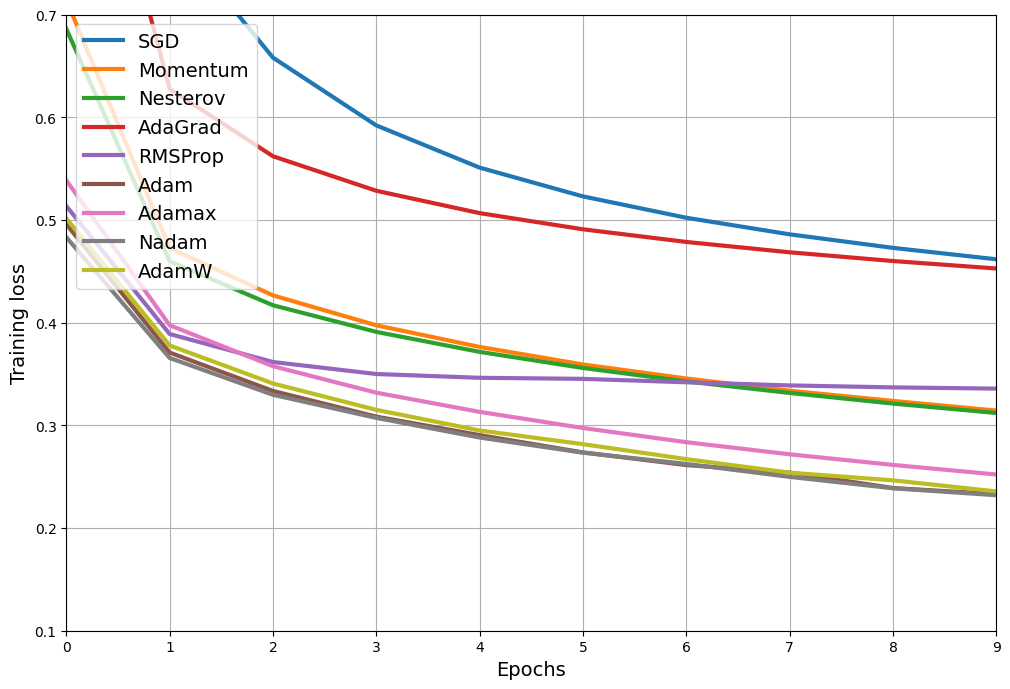

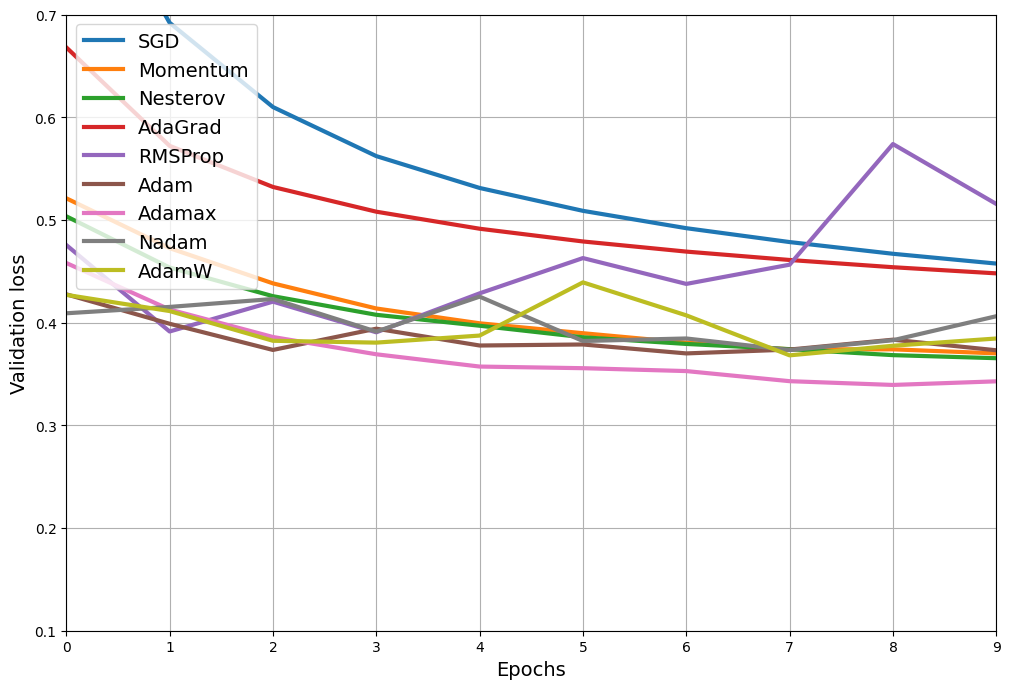

In [27]:
# extra code – visualize the learning curves of all the optimizers

for loss in ("loss", "val_loss"):
    plt.figure(figsize=(12, 8))
    opt_names = "SGD Momentum Nesterov AdaGrad RMSProp Adam Adamax Nadam AdamW"
    for history, opt_name in zip((history_sgd, history_momentum, history_nesterov,
                                  history_adagrad, history_rmsprop, history_adam,
                                  history_adamax, history_nadam, history_adamw),
                                 opt_names.split()):
        plt.plot(history.history[loss], label=f"{opt_name}", linewidth=3)

    plt.grid()
    plt.xlabel("Epochs")
    plt.ylabel({"loss": "Training loss", "val_loss": "Validation loss"}[loss])
    plt.legend(loc="upper left")
    plt.axis([0, 9, 0.1, 0.7])
    plt.show()

In [35]:
# history_sgd.history["accuracy"]

# Learning Rate Schedulingm

* **Learning rate (η) is critical** for training performance

* If learning rate is:

  * **Too high**:

    * Training diverges (loss increases)

  * **Too low**:

    * Very slow convergence
    * Takes long time to reach optimum

  * **Slightly too high**:

    * Fast initial progress
    * Oscillates around optimum
    * Never fully converges

* Practical issue:

  * Limited compute → may stop training early
  * Leads to **suboptimal solution**

* **Finding a good learning rate**:

  * Method:

    * Start with very small η
    * Gradually increase exponentially
    * Train for a few hundred iterations

  * Observe learning curve:

    * Loss decreases → good region
    * Loss suddenly increases → too high

  * Choose:

    * Learning rate **just below the divergence point**

  * Then:

    * Reinitialize model
    * Train with selected learning rate

* Limitation of constant learning rate:

  * Not optimal throughout training

* Better approach → **Learning Schedules**:

  * Idea:

    * Change learning rate during training

* Common strategies:

  * Start with **high learning rate**:

    * Fast initial learning

  * Then **reduce learning rate**:

    * Fine-tune near optimum

* Alternative strategy:

  * Start low → increase → decrease
  * Helps stabilize early training

* Benefits of learning schedules:

  * Faster convergence
  * Better final performance
  * Avoid oscillations near optimum

* Key takeaway:

  * Learning rate should **adapt during training**, not stay constant
  * Proper scheduling can significantly improve both **speed and accuracy** 🚀


## Power scheduling

* **Power Scheduling (Learning Rate Decay)**:

  * Learning rate decreases as training progresses

* Formula:

  * η(t) = η₀ / (1 + t / s)ᶜ

* Components:

  * η₀ → initial learning rate
  * t → iteration number
  * s → decay steps (controls speed of decay)
  * c → power (usually c = 1)

* Behavior:

  * At t = 0:

    * η(t) = η₀

  * After s steps:

    * η(t) = η₀ / 2

  * After 2s steps:

    * η(t) = η₀ / 3

  * After 3s steps:

    * η(t) = η₀ / 4

* Key pattern:

  * **Fast decrease initially**
  * Then **slower and smoother decay** over time

* Advantages:

  * Large learning rate at start → fast progress
  * Smaller learning rate later → fine-tuning

* Hyperparameters to tune:

  * η₀ → starting learning rate
  * s → controls decay speed
  * c → controls curve shape (usually 1)

* Insight:

  * Prevents:

    * overshooting early
    * instability later

* Key takeaway:

  * Power scheduling provides a **gradual and smooth reduction** in learning rate, balancing speed and stability during training 🚀


```python
learning_rate = initial_learning_rate / (1 + step / decay_steps)**power
```

Keras uses `power = 1`.

In [36]:
lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
    initial_learning_rate=0.01,
    decay_steps=10_000,
    decay_rate=1.0,
    staircase=False
)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)

The `InverseTimeDecay` scheduler uses `learning_rate = initial_learning_rate / (1 + decay_rate * step / decay_steps)`. If you set `staircase=True`, then it replaces `step / decay_step` with `floor(step / decay_step)`.

In [37]:
history_power_scheduling = build_and_train_model(optimizer)  # extra code

C:\Users\roush\ml_env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7548 - loss: 0.7160 - val_accuracy: 0.8296 - val_loss: 0.5084
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8313 - loss: 0.4832 - val_accuracy: 0.8358 - val_loss: 0.4587
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8474 - loss: 0.4365 - val_accuracy: 0.8438 - val_loss: 0.4356
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8558 - loss: 0.4101 - val_accuracy: 0.8472 - val_loss: 0.4212
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8618 - loss: 0.3922 - val_accuracy: 0.8514 - val_loss: 0.4094
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8666 - loss: 0.3786 - val_accuracy: 0.8546 - val_loss: 0.3990
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8706 - loss: 0.3678 - val_accuracy: 0.8558 - val_loss: 0.3905
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8733 - loss: 0.3589

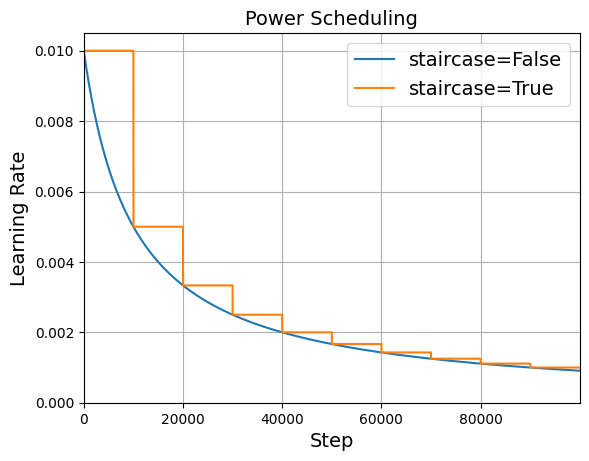

In [39]:
# extra code – this cell plots power scheduling with staircase=True or False
import numpy as np
initial_learning_rate = 0.01
decay_rate = 1.0
decay_steps = 10_000

steps = np.arange(100_000)
lrs = initial_learning_rate / (1 + decay_rate * steps / decay_steps)
lrs2 = initial_learning_rate / (1 + decay_rate * np.floor(steps / decay_steps))

plt.plot(steps, lrs,  "-", label="staircase=False")
plt.plot(steps, lrs2,  "-", label="staircase=True")
plt.axis([0, steps.max(), 0, 0.0105])
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title("Power Scheduling", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

## Exponential scheduling

* **Exponential Scheduling (Learning Rate Decay)**:

  * Learning rate decreases **exponentially over time**

* Formula:

  * η(t) = η₀ × 0.1^(t / s)

* Components:

  * η₀ → initial learning rate
  * t → iteration number
  * s → decay step (controls when drop happens)

* Behavior:

  * Every **s steps**:

    * Learning rate is multiplied by **0.1 (drops 10×)**

  * Example:

    * t = 0 → η = η₀
    * t = s → η = 0.1η₀
    * t = 2s → η = 0.01η₀
    * t = 3s → η = 0.001η₀

* Key characteristic:

  * **Consistent multiplicative decay**
  * Drops sharply at regular intervals

* Comparison with Power Scheduling:

  * Power scheduling:

    * Fast drop initially → then slows down

  * Exponential scheduling:

    * Keeps reducing **at constant ratio (×0.1)**

* Advantages:

  * Simple and predictable
  * Effective for staged training

* Drawback:

  * Can reduce learning rate **too aggressively**
  * May slow training too early if s is small

* Hyperparameter:

  * s → controls how frequently learning rate drops

* Key takeaway:

  * Exponential scheduling applies **regular sharp reductions** in learning rate, useful for controlled step-wise convergence 🚀


```python
learning_rate = initial_learning_rate * decay_rate ** (step / decay_steps)
```

In [41]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=20_000,
    decay_rate=0.1,
    staircase=False
)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)

In [42]:
history_exponential_scheduling = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7713 - loss: 0.6714 - val_accuracy: 0.8216 - val_loss: 0.5000
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8357 - loss: 0.4675 - val_accuracy: 0.8344 - val_loss: 0.4563
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8501 - loss: 0.4244 - val_accuracy: 0.8438 - val_loss: 0.4323
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8579 - loss: 0.4002 - val_accuracy: 0.8490 - val_loss: 0.4151
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8638 - loss: 0.3841 - val_accuracy: 0.8520 - val_loss: 0.4030
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8679 - loss: 0.3724 - val_accuracy: 0.8576 - val_loss: 0.3931
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8716 - loss: 0.3635 - val_accuracy: 0.8606 - val_loss: 0.3846
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8743 - loss: 0.3566 

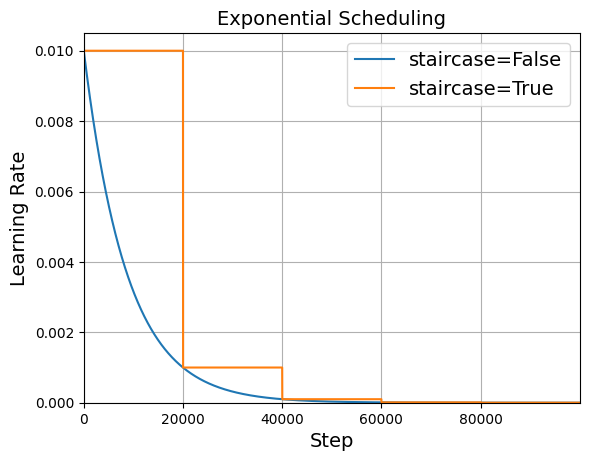

In [43]:
# extra code – this cell plots exponential scheduling

initial_learning_rate = 0.01
decay_rate = 0.1
decay_steps = 20_000

steps = np.arange(100_000)
lrs = initial_learning_rate * decay_rate ** (steps / decay_steps)
lrs2 = initial_learning_rate * decay_rate ** np.floor(steps / decay_steps)

plt.plot(steps, lrs,  "-", label="staircase=False")
plt.plot(steps, lrs2,  "-", label="staircase=True")
plt.axis([0, steps.max(), 0, 0.0105])
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title("Exponential Scheduling", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

Keras also provides a `LearningRateScheduler` callback class that lets you define your own scheduling function. Let's see how you could use it to implement exponential decay. Note that in this case the learning rate only changes at each epoch, not at each step:

In [44]:
def exponential_decay_fn(epoch):
    return 0.01 * 0.1 ** (epoch / 20)

In [45]:
def exponential_decay(lr0, s):
    def exponential_decay_fn(epoch):
        return lr0 * 0.1 ** (epoch / s)
    return exponential_decay_fn

exponential_decay_fn = exponential_decay(lr0=0.01, s=20)

In [48]:
# extra code – build and compile a model for Fashion MNIST

tf.random.set_seed(42)
model = build_model()
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

In [49]:
n_epochs = 20

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(exponential_decay_fn)
history = model.fit(X_train, y_train, epochs=n_epochs,
                    validation_data=(X_valid, y_valid),
                    callbacks=[lr_scheduler])

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7671 - loss: 0.6810 - val_accuracy: 0.8152 - val_loss: 0.5007 - learning_rate: 0.0100
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8347 - loss: 0.4678 - val_accuracy: 0.8320 - val_loss: 0.4525 - learning_rate: 0.0089
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8497 - loss: 0.4208 - val_accuracy: 0.8424 - val_loss: 0.4241 - learning_rate: 0.0079
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8588 - loss: 0.3934 - val_accuracy: 0.8518 - val_loss: 0.4072 - learning_rate: 0.0071
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8654 - loss: 0.3750 - val_accuracy: 0.8590 - val_loss: 0.3942 - learning_rate: 0.0063
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8705 - loss: 0.3612 - val_accuracy: 0.8618 - val_loss: 0.3831 - learning_rate: 0.0056
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8749

Alternatively, the schedule function can take the current learning rate as a second argument:

In [50]:
def exponential_decay_fn(epoch, lr):
    return lr * 0.1 ** (1 / 20)

>Extra material: if you want to use a custom scheduling function that updates the learning rate at each iteration rather than at each epoch, you can write your own callback class like this:

In [51]:
K = tf.keras.backend

class ExponentialDecay(tf.keras.callbacks.Callback):
    def __init__(self, n_steps=40_000):
        super().__init__()
        self.n_steps = n_steps

    def on_batch_begin(self, batch, logs=None):
        # Note: the `batch` argument is reset at each epoch
        lr = self.model.optimizer.learning_rate.numpy()
        new_learning_rate = lr * 0.1 ** (1 / self.n_steps)
        self.model.optimizer.learning_rate = new_learning_rate

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        logs['lr'] = self.model.optimizer.learning_rate.numpy()

In [52]:
lr0 = 0.01
model = build_model()
optimizer = tf.keras.optimizers.SGD(learning_rate=lr0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

In [53]:
import math

batch_size = 32
n_steps = n_epochs * math.ceil(len(X_train) / batch_size)
exp_decay = ExponentialDecay(n_steps)
history = model.fit(X_train, y_train, epochs=n_epochs,
                    validation_data=(X_valid, y_valid),
                    callbacks=[exp_decay])

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7588 - loss: 0.7026 - val_accuracy: 0.8266 - val_loss: 0.4960 - lr: 0.0089
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8308 - loss: 0.4767 - val_accuracy: 0.8404 - val_loss: 0.4463 - lr: 0.0079
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8475 - loss: 0.4293 - val_accuracy: 0.8472 - val_loss: 0.4230 - lr: 0.0071
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8572 - loss: 0.4022 - val_accuracy: 0.8492 - val_loss: 0.4094 - lr: 0.0063
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8629 - loss: 0.3836 - val_accuracy: 0.8526 - val_loss: 0.3973 - lr: 0.0056
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8675 - loss: 0.3693 - val_accuracy: 0.8570 - val_loss: 0.3887 - lr: 0.0050
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8715 - loss: 0.3581 - val_accuracy: 0.8590 - val_loss: 0.3823 - lr:

## Piecewise constant scheduling

* **Piecewise Constant Scheduling**:

  * Learning rate is kept **constant for fixed intervals**, then reduced

* Strategy:

  * Use one learning rate for a few epochs
  * Then switch to a smaller learning rate
  * Repeat if needed

* Example:

  * η = 0.1 → first 5 epochs
  * η = 0.001 → next 50 epochs
  * η = 0.0001 → later epochs

* Behavior:

  * Step-wise decrease
  * Sudden drops instead of smooth decay

* Advantages:

  * Simple and easy to understand
  * Can work very well in practice

* Drawback:

  * Requires **manual tuning**:

    * When to change learning rate
    * What values to use

* Insight:

  * Good when you:

    * know training phases
    * want controlled adjustments

* Key takeaway:

  * Piecewise scheduling is effective but **less flexible**, as it depends heavily on manual tuning 🚀


In [54]:
lr_schedule = tf.keras.optimizers.schedules.PiecewiseConstantDecay(
    boundaries = [50_000 * n_epochs // batch_size, 80_000 * n_epochs // batch_size] ,
    values=[0.01, 0.005, 0.001]
)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)

In [55]:
history_piecewise_scheduling = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7757 - loss: 0.6645 - val_accuracy: 0.8356 - val_loss: 0.4676
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8404 - loss: 0.4581 - val_accuracy: 0.8496 - val_loss: 0.4291
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8540 - loss: 0.4138 - val_accuracy: 0.8534 - val_loss: 0.4062
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8624 - loss: 0.3869 - val_accuracy: 0.8574 - val_loss: 0.3930
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8679 - loss: 0.3675 - val_accuracy: 0.8598 - val_loss: 0.3820
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8720 - loss: 0.3525 - val_accuracy: 0.8620 - val_loss: 0.3773
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8763 - loss: 0.3397 - val_accuracy: 0.8632 - val_loss: 0.3721
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8804 - loss: 0.32

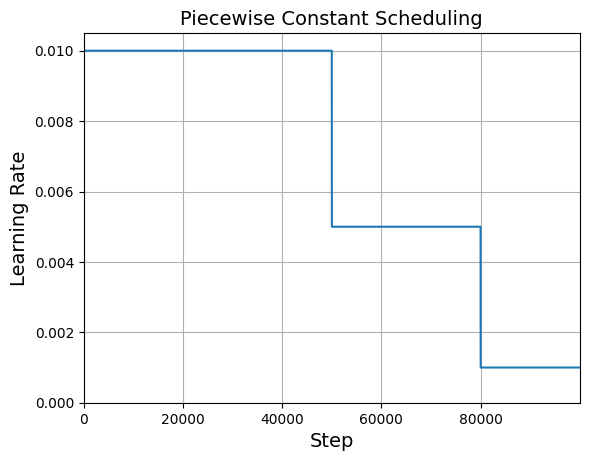

In [56]:
# extra code – this cell plots piecewise constant scheduling

boundaries = [50_000, 80_000]
values = [0.01, 0.005, 0.001]

steps = np.arange(100_000)

lrs = np.full(len(steps), values[0])
for boundary, value in zip(boundaries, values[1:]):
    lrs[boundary:] = value

plt.plot(steps, lrs, "-")
plt.axis([0, steps.max(), 0, 0.0105])
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title("Piecewise Constant Scheduling", fontsize=14)
plt.grid(True)
plt.show()

Just like we did with exponential scheduling, we could also implement piecewise constant scheduling manually:

In [57]:
def piecewise_constant_fn(epoch):
    if epoch < 5:
        return 0.01
    elif epoch < 15:
        return 0.005
    else:
        return 0.001

In [58]:
# extra code – this cell demonstrates a more general way to define
#              piecewise constant scheduling.

def piecewise_constant(boundaries, values):
    boundaries = np.array([0] + boundaries)
    values = np.array(values)
    def piecewise_constant_fn(epoch):
        return values[(boundaries > epoch).argmax() - 1]
    return piecewise_constant_fn

piecewise_constant_fn = piecewise_constant([5, 15], [0.01, 0.005, 0.001])

In [59]:
# extra code – use a tf.keras.callbacks.LearningRateScheduler like earlier

n_epochs = 25

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(piecewise_constant_fn)

model = build_model()
optimizer = tf.keras.optimizers.Nadam(learning_rate=lr0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=n_epochs,
                    validation_data=(X_valid, y_valid),
                    callbacks=[lr_scheduler])

Epoch 1/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.8094 - loss: 0.5385 - val_accuracy: 0.8310 - val_loss: 0.4544 - learning_rate: 0.0100
Epoch 2/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.8432 - loss: 0.4463 - val_accuracy: 0.8372 - val_loss: 0.4617 - learning_rate: 0.0100
Epoch 3/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8490 - loss: 0.4278 - val_accuracy: 0.8438 - val_loss: 0.4359 - learning_rate: 0.0100
Epoch 4/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8523 - loss: 0.4135 - val_accuracy: 0.8526 - val_loss: 0.4370 - learning_rate: 0.0100
Epoch 5/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8565 - loss: 0.4122 - val_accuracy: 0.8508 - val_loss: 0.4307 - learning_rate: 0.0100
Epoch 6/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8721 - loss: 0.3529 - val_accuracy: 0.8526 - val_loss: 0.4033 - learning_rate: 0.0050
Epoch 7/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.87

We've looked at `InverseTimeDecay`, `ExponentialDecay`, and `PiecewiseConstantDecay`. A few more schedulers are available in `tf.keras.optimizers.schedules`, here is the full list:

In [60]:
for name in sorted(dir(tf.keras.optimizers.schedules)):
    if name[0] == name[0].lower():  # must start with capital letter
        continue
    scheduler_class = getattr(tf.keras.optimizers.schedules, name)
    print(f"• {name} – {scheduler_class.__doc__.splitlines()[0]}")

• CosineDecay – A `LearningRateSchedule` that uses a cosine decay with optional warmup.
• CosineDecayRestarts – A `LearningRateSchedule` that uses a cosine decay schedule with restarts.
• ExponentialDecay – A `LearningRateSchedule` that uses an exponential decay schedule.
• InverseTimeDecay – A `LearningRateSchedule` that uses an inverse time decay schedule.
• LearningRateSchedule – The learning rate schedule base class.
• PiecewiseConstantDecay – A `LearningRateSchedule` that uses a piecewise constant decay schedule.
• PolynomialDecay – A `LearningRateSchedule` that uses a polynomial decay schedule.


## Performance scheduling

* **Performance-based Scheduling (Reduce on Plateau)**:

  * Adjust learning rate based on **validation performance**

* Strategy:

  * Monitor **validation error (or loss)** every N steps
  * If error **stops improving**:

    * Reduce learning rate

* Rule:

  * If no improvement for some time:

    * η ← η × λ
  * Where:

    * λ < 1 (e.g., 0.1 or 0.5)

* Behavior:

  * Learning rate stays constant while improving
  * Drops only when progress stalls

* Advantages:

  * **Adaptive** → reacts to training progress
  * Reduces need for manual scheduling
  * Helps fine-tune near optimum

* Hyperparameters:

  * N → how often to check validation error
  * λ → reduction factor
  * patience → how long to wait before reducing

* Benefit:

  * Prevents wasting time with high learning rate
  * Improves convergence stability

* Common usage (Keras):

  * ReduceLROnPlateau callback

* Key takeaway:

  * Dynamically lowers learning rate when progress slows, making training **more efficient and automated** 🚀


In [61]:
# extra code – build and compile the model

model = build_model()
optimizer = tf.keras.optimizers.SGD(learning_rate=lr0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

In [62]:
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
history = model.fit(X_train, y_train, epochs=n_epochs,
                    validation_data=(X_valid, y_valid),
                    callbacks=[lr_scheduler])

Epoch 1/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7726 - loss: 0.6681 - val_accuracy: 0.8304 - val_loss: 0.4845 - learning_rate: 0.0100
Epoch 2/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8341 - loss: 0.4682 - val_accuracy: 0.8376 - val_loss: 0.4389 - learning_rate: 0.0100
Epoch 3/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8494 - loss: 0.4226 - val_accuracy: 0.8450 - val_loss: 0.4180 - learning_rate: 0.0100
Epoch 4/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8590 - loss: 0.3944 - val_accuracy: 0.8516 - val_loss: 0.4034 - learning_rate: 0.0100
Epoch 5/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8654 - loss: 0.3739 - val_accuracy: 0.8532 - val_loss: 0.3927 - learning_rate: 0.0100
Epoch 6/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8704 - loss: 0.3579 - val_accuracy: 0.8550 - val_loss: 0.3830 - learning_rate: 0.0100
Epoch 7/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8743 -

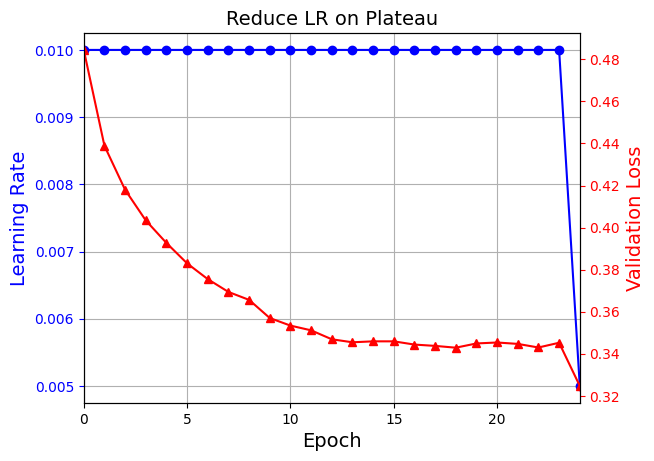

In [63]:
# extra code – this cell plots performance scheduling

plt.plot(history.epoch, history.history["learning_rate"], "bo-")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate", color='b')
plt.tick_params('y', colors='b')
plt.gca().set_xlim(0, n_epochs - 1)
plt.grid(True)

ax2 = plt.gca().twinx()
ax2.plot(history.epoch, history.history["val_loss"], "r^-")
ax2.set_ylabel('Validation Loss', color='r')
ax2.tick_params('y', colors='r')

plt.title("Reduce LR on Plateau", fontsize=14)
plt.show()

## 1cycle scheduling

* **1cycle Learning Rate Policy**:

  * Introduced by **Leslie Smith (2018)**
  * A dynamic learning schedule that **first increases, then decreases** learning rate

* Learning rate behavior:

  * Start with **low learning rate (η₀)**
  * Increase **linearly → η_max** (first half of training)
  * Decrease **linearly → η₀** (second half)
  * Final phase:

    * Drop learning rate **very sharply (several orders lower)**

* Key values:

  * η_max → chosen using learning rate finder
  * η₀ → typically **η_max / 10**

* Momentum scheduling (important):

  * Start with **high momentum** (e.g., 0.95)
  * Decrease to **lower value** (e.g., 0.85) during first half
  * Increase back to **high value** in second half
  * Stay high in final phase

* Intuition:

  * High learning rate:

    * Helps explore parameter space
    * Avoids local minima

  * Low learning rate:

    * Helps fine-tune near optimum

* Benefits:

  * Much **faster training**
  * Often **better generalization**
  * Can achieve strong results in fewer epochs

* Example result:

  * CIFAR-10:

    * 91.9% accuracy in **100 epochs** (1cycle)
    * vs 90.3% in **800 epochs** (standard training)

* Concept → **Super Convergence**:

  * Achieving high performance in **very few epochs**

* Key insight:

  * Instead of slowly decreasing LR:

    * First increase → explore
    * Then decrease → refine

* Key takeaway:

  * 1cycle policy is a powerful scheduling technique that can **dramatically speed up training and improve results** 🚀


The `ExponentialLearningRate` custom callback updates the learning rate during training, at the end of each batch. It multiplies it by a constant `factor`. It also saves the learning rate and loss at each batch. Since `logs["loss"]` is actually the mean loss since the start of the epoch, and we want to save the batch loss instead, we must compute the mean times the number of batches since the beginning of the epoch to get the total loss so far, then we subtract the total loss at the previous batch to get the current batch's loss.

In [64]:
K = tf.keras.backend

class ExponentialLearningRate(tf.keras.callbacks.Callback):
    def __init__(self, factor):
        self.factor = factor
        self.rates = []
        self.losses = []

    def on_epoch_begin(self, epoch, logs=None):
        self.sum_of_epoch_losses = 0

    def on_batch_end(self, batch, logs=None):
        mean_epoch_loss = logs["loss"]  # the epoch's mean loss so far 
        new_sum_of_epoch_losses = mean_epoch_loss * (batch + 1)
        batch_loss = new_sum_of_epoch_losses - self.sum_of_epoch_losses
        self.sum_of_epoch_losses = new_sum_of_epoch_losses
        lr = self.model.optimizer.learning_rate.numpy()
        self.rates.append(lr)
        self.losses.append(batch_loss)
        self.model.optimizer.learning_rate = lr * self.factor

The `find_learning_rate()` function trains the model using the `ExponentialLearningRate` callback, and it returns the learning rates and corresponding batch losses. At the end, it restores the model and its optimizer to their initial state.

In [66]:
def find_learning_rate(model, X, y, epochs=1, batch_size=32, min_rate=1e-4,
                       max_rate=1):
    init_weights = model.get_weights()
    iterations = math.ceil(len(X) / batch_size) * epochs
    factor = (max_rate / min_rate) ** (1 / iterations)
    init_lr = K.get_value(model.optimizer.learning_rate)
    model.optimizer.learning_rate = min_rate
    exp_lr = ExponentialLearningRate(factor)
    history = model.fit(X, y, epochs=epochs, batch_size=batch_size,
                        callbacks=[exp_lr])
    model.optimizer.learning_rate = init_lr
    model.set_weights(init_weights)
    return exp_lr.rates, exp_lr.losses

The `plot_lr_vs_loss()` function plots the learning rates vs the losses. The optimal learning rate to use as the maximum learning rate in 1cycle is near the bottom of the curve.

In [67]:
def plot_lr_vs_loss(rates, losses):
    plt.plot(rates, losses, "b")
    plt.gca().set_xscale('log')
    max_loss = losses[0] + min(losses)
    plt.hlines(min(losses), min(rates), max(rates), color="k")
    plt.axis([min(rates), max(rates), 0, max_loss])
    plt.xlabel("Learning rate")
    plt.ylabel("Loss")
    plt.grid()

Let's build a simple Fashion MNIST model and compile it:

In [69]:
model = build_model()
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
              metrics=["accuracy"])

In [70]:
# Now let's find the optimal max learning rate for 1cycle:

430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.3727 - loss: 1.7800


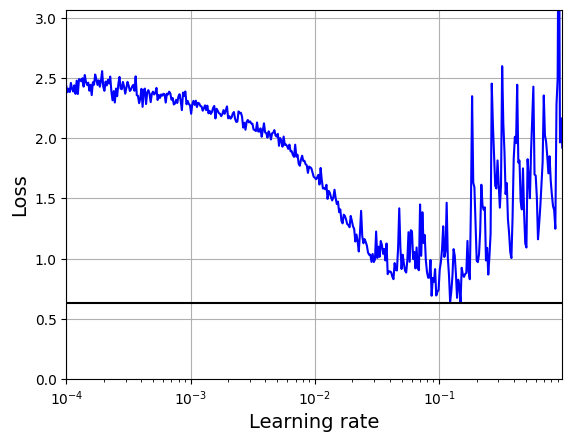

In [71]:
batch_size = 128
rates, losses = find_learning_rate(model, X_train, y_train, epochs=1,
                                   batch_size=batch_size)
plot_lr_vs_loss(rates, losses)

The `OneCycleScheduler` custom callback updates the learning rate at the beginning of each batch. It applies the logic described in the book: increase the learning rate linearly during about half of training, then reduce it linearly back to the initial learning rate, and lastly reduce it down to close to zero linearly for the very last part of training.

In [72]:
class OneCycleScheduler(tf.keras.callbacks.Callback):
    def __init__(self, iterations, max_lr=1e-3, start_lr=None,
                 last_iterations=None, last_lr=None):
        self.iterations = iterations
        self.max_lr = max_lr
        self.start_lr = start_lr or max_lr / 10
        self.last_iterations = last_iterations or iterations // 10 + 1
        self.half_iteration = (iterations - self.last_iterations) // 2
        self.last_lr = last_lr or self.start_lr / 1000
        self.iteration = 0

    def _interpolate(self, iter1, iter2, lr1, lr2):
        return (lr2 - lr1) * (self.iteration - iter1) / (iter2 - iter1) + lr1

    def on_batch_begin(self, batch, logs):
        if self.iteration < self.half_iteration:
            lr = self._interpolate(0, self.half_iteration, self.start_lr,
                                   self.max_lr)
        elif self.iteration < 2 * self.half_iteration:
            lr = self._interpolate(self.half_iteration, 2 * self.half_iteration,
                                   self.max_lr, self.start_lr)
        else:
            lr = self._interpolate(2 * self.half_iteration, self.iterations,
                                   self.start_lr, self.last_lr)
        self.iteration += 1
        self.model.optimizer.learning_rate = lr

In [73]:
# Let's build and compile a simple Fashion MNIST model, then train it using the `OneCycleScheduler` callback:
model = build_model()
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["accuracy"])
n_epochs = 25
onecycle = OneCycleScheduler(math.ceil(len(X_train) / batch_size) * n_epochs,
                             max_lr=0.1)
history = model.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
                    validation_data=(X_valid, y_valid),
                    callbacks=[onecycle])

Epoch 1/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6507 - loss: 1.0664 - val_accuracy: 0.8034 - val_loss: 0.5997
Epoch 2/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8015 - loss: 0.5690 - val_accuracy: 0.8260 - val_loss: 0.4971
Epoch 3/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8258 - loss: 0.4954 - val_accuracy: 0.8254 - val_loss: 0.4803
Epoch 4/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8395 - loss: 0.4538 - val_accuracy: 0.8154 - val_loss: 0.4994
Epoch 5/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8483 - loss: 0.4238 - val_accuracy: 0.8122 - val_loss: 0.5102
Epoch 6/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8557 - loss: 0.4009 - val_accuracy: 0.8040 - val_loss: 0.5248
Epoch 7/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8614 - loss: 0.3812 - val_accuracy: 0.8042 - val_loss: 0.5394
Epoch 8/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8675 - loss: 0.3654 - val_accuracy: 0.

* **Empirical findings (Andrew Senior et al., 2013)**:

  * Compared learning schedules for deep neural networks
  * Found:

    * **Exponential scheduling** → slightly faster convergence
    * **Performance scheduling** → also effective
  * Preferred exponential because:

    * Easier to tune
    * Simpler to implement 

* Overall conclusion:

  * **1cycle policy** often performs even better than both

---

* **Power Scheduling in Keras**:

  * Use `decay` parameter in optimizer:

  * optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, decay=1e-4)

  * decay ≈ 1 / s (step parameter)

---

* **Exponential Scheduling (Keras implementation)**:

  * Define function:

    def exponential_decay_fn(epoch):
    return 0.01 * 0.1 ** (epoch / 20)

  * Or generalized version:

    def exponential_decay(lr0, s):
    def exponential_decay_fn(epoch):
    return lr0 * 0.1 ** (epoch / s)
    return exponential_decay_fn

* Apply using callback:

  * lr_scheduler = tf.keras.callbacks.LearningRateScheduler(exponential_decay_fn)
  * model.fit(..., callbacks=[lr_scheduler])

---

* **Important detail**:

  * Learning rate updated:

    * Usually **per epoch**
    * Can customize to update **per step**

* After training:

  * history.history["lr"] → gives learning rate history

---

* **Alternative implementation (step-based scheduling)**:

  * Use built-in schedules:

    scheduled_learning_rate = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=n_steps,
    decay_rate=0.1
    )

  * optimizer = tf.keras.optimizers.SGD(learning_rate=scheduled_learning_rate)

* Advantage:

  * Updates **every step (not epoch)**
  * Saved with model automatically

---

* **Piecewise Constant Scheduling**:

  * Example:

    def piecewise_constant_fn(epoch):
    if epoch < 5:
    return 0.01
    elif epoch < 15:
    return 0.005
    else:
    return 0.001

---

* **Performance Scheduling (Keras)**:

  * Use:

    tf.keras.callbacks.ReduceLROnPlateau

  * Example:

    lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    factor=0.5, patience=5
    )

* Behavior:

  * Reduce LR when validation loss stops improving

---

* **Important warning (continuing training)**:

  * If using epoch-based schedule:

    * Epoch resets when calling `fit()` again
    * Can cause **wrong learning rate**

  * Fix:

    * Use `initial_epoch` parameter

---

* **1cycle in Keras**:

  * Not built-in

  * Implement via **custom callback**

  * Update LR inside:

    * on_batch_begin()

  * Use:

    * tf.keras.backend.set_value(...)

---

* **Final takeaway**:

  * Best learning schedules:

    * **Exponential decay → simple & reliable**
    * **ReduceLROnPlateau → adaptive**
    * **1cycle → fastest & often best performance**

  * Learning rate scheduling is a **major factor in convergence speed and final accuracy** 🚀


# Avoiding Overfitting Through Regularization

* Famous quote insight:

  * With enough parameters → model can **fit almost anything**
  * Deep neural networks:

    * Have **thousands to millions of parameters**

* Advantage:

  * Can model **very complex patterns**

* Problem:

  * High flexibility → **overfitting**
  * Model memorizes training data instead of generalizing

* Solution → **Regularization**:

  * Techniques to reduce overfitting
  * Improve generalization

* Already covered techniques:

  * **Early Stopping**:

    * Stop training before overfitting begins

  * **Batch Normalization**:

    * Stabilizes training
    * Also acts as **regularizer**

* Additional regularization techniques:

  * **L1 Regularization**:

    * Adds penalty: sum of absolute weights
    * Encourages **sparse models** (many weights = 0)

  * **L2 Regularization**:

    * Adds penalty: sum of squared weights
    * Keeps weights **small and smooth**

  * **Dropout**:

    * Randomly disables neurons during training
    * Prevents co-dependency between neurons

  * **Max-Norm Regularization**:

    * Constrains maximum size of weights
    * Prevents weights from growing too large

* Key insight:

  * Regularization **controls model complexity**

* Trade-off:

  * Too little → overfitting
  * Too much → underfitting

* Key takeaway:

  * Deep networks are powerful but need **regularization techniques** to generalize well 🚀


## $ℓ_1$ and $ℓ_2$ Regularization

* **L1 and L2 Regularization in Neural Networks**:

  * Same concept as in linear models
  * Applied to **weights of neural network layers**

* **L2 Regularization (Ridge)**:

  * Penalizes squared weights

  * Keeps weights **small and smooth**

  * Loss becomes:

    * Loss = original_loss + λ ∑ w²

* **L1 Regularization (Lasso)**:

  * Penalizes absolute weights

  * Drives many weights → **0 (sparse model)**

  * Loss becomes:

    * Loss = original_loss + λ ∑ |w|

* **Applying L2 in Keras**:

  * Example:

    layer = tf.keras.layers.Dense(
    100,
    activation="relu",
    kernel_initializer="he_normal",
    kernel_regularizer=tf.keras.regularizers.l2(0.01)
    )

* How it works:

  * Regularizer computes **penalty term**
  * Added to total loss during training

* Other options:

  * L1:

    * tf.keras.regularizers.l1(λ)

  * L1 + L2:

    * tf.keras.regularizers.l1_l2(l1=..., l2=...)

* Problem in practice:

  * Repeating same arguments for many layers → messy code

* Solution → **functools.partial()**:

  * Create reusable layer template:

    from functools import partial

    RegularizedDense = partial(
    tf.keras.layers.Dense,
    activation="relu",
    kernel_initializer="he_normal",
    kernel_regularizer=tf.keras.regularizers.l2(0.01)
    )

* Then use:

  * RegularizedDense(100)

* Benefit:

  * Cleaner code
  * Less repetition
  * Fewer errors

* Important warning:

  * L2 regularization works well with:

    * SGD
    * Momentum
    * Nesterov

  * NOT ideal with:

    * Adam and its variants

* If using Adam:

  * Use **AdamW (weight decay)** instead of L2

* Key takeaway:

  * L1 → sparsity
  * L2 → stability and small weights
  * Use correct combination with optimizer for best results 🚀


In [7]:
layer = tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal",
                              kernel_regularizer=tf.keras.regularizers.l2(0.01))

In [8]:
tf.random.set_seed(42)  # extra code – for reproducibility

In [9]:
from functools import partial

RegularizedDense = partial(tf.keras.layers.Dense,
                           activation="relu",
                           kernel_initializer="he_normal",
                           kernel_regularizer=tf.keras.regularizers.l2(0.01))

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    RegularizedDense(100),
    RegularizedDense(100),
    RegularizedDense(10, activation="softmax",
                     kernel_initializer="glorot_normal")  # not in the book
])

C:\Users\roush\ml_env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
# extra code – compile and train the model
optimizer = tf.keras.optimizers.SGD(learning_rate=0.02)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=2,
                    validation_data=(X_valid, y_valid))

Epoch 1/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7670 - loss: 3.1381 - val_accuracy: 0.8216 - val_loss: 1.8628
Epoch 2/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8141 - loss: 1.4293 - val_accuracy: 0.8228 - val_loss: 1.1200


## Dropout

* **Dropout**:

  * One of the most effective **regularization techniques**
  * Introduced by **Geoffrey Hinton (2012)**

* Impact:

  * Typically improves accuracy by **1–2%**
  * Can significantly reduce error rate (e.g., 5% → ~3%)

* Core idea:

  * During training:

    * Randomly **disable (drop)** neurons
  * During testing:

    * Use full network (no dropout)

* Mechanism:

  * Each neuron has probability **p** of being dropped
  * Dropped neuron:

    * Does not participate in forward pass
    * Does not receive gradient updates

* Dropout rate (p):

  * Typical values:

    * 10%–50%

  * Common practice:

    * RNNs → 20–30%
    * CNNs → 40–50%

* Important detail:

  * Applied to:

    * Hidden layers
    * Input layer (sometimes)
  * Not applied to:

    * Output layer

* Intuition:

  * Prevents neurons from:

    * Relying on specific other neurons
    * Forming strong dependencies

  * Forces each neuron to:

    * Learn **independent and useful features**

* Analogy:

  * Like randomly removing team members:

    * System must adapt
    * Knowledge spreads across team

* Effects:

  * Reduces **co-adaptation of neurons**
  * Encourages **redundancy in representations**
  * Makes model more **robust to input changes**

* Result:

  * Better **generalization**
  * Reduced **overfitting**

* Key takeaway:

  * Dropout acts like training many smaller networks and averaging them, leading to a **stronger and more reliable model** 🚀


* **Dropout as Ensemble Learning**:

  * Each training step creates a **different neural network**
  * Total possible networks:

    * 2^N (N = number of droppable neurons)

* Insight:

  * Practically impossible to train the same network twice
  * After many steps:

    * Model ≈ **ensemble of many subnetworks**

* Effect:

  * Acts like **model averaging**
  * Improves generalization

---

* **Where to apply dropout**:

  * Usually:

    * Top **1–3 hidden layers**
  * Avoid:

    * Output layer

---

* **Important scaling detail**:

  * If dropout rate = p

  * Keep probability = (1 − p)

  * During training:

    * Active neurons are fewer
    * To compensate:

      * Scale inputs by:
        1 / (1 − p)

* Reason:

  * Ensures:

    * Same expected output during training and testing

---

* **Keras implementation**:

  * Example:

    model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(100, activation="relu",
    kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(100, activation="relu",
    kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(10, activation="softmax")
    ])

* Behavior:

  * Training:

    * Random neurons dropped
    * Remaining scaled
  * Testing:

    * No dropout
    * Normal forward pass

---

* **Important warning**:

  * Training loss vs validation loss:

    * Can be misleading
    * Because dropout only active during training

  * Solution:

    * Evaluate training loss **without dropout**

---

* **Tuning dropout rate**:

  * If **overfitting**:

    * Increase dropout rate

  * If **underfitting**:

    * Decrease dropout rate

  * Large layers → higher dropout

  * Small layers → lower dropout

---

* **Alternative strategy**:

  * Use dropout only:

    * After last hidden layer
  * Common in modern architectures

---

* **Drawback**:

  * Slows down training (convergence)

* Benefit:

  * Better generalization
  * Often worth the trade-off

---

* **Special case (SELU networks)**:

  * Use **Alpha Dropout** instead of standard dropout
  * Preserves:

    * Mean
    * Variance
  * Maintains **self-normalization**

---

* **Key takeaway**:

  * Dropout = **implicit ensemble + noise injection**
  * Makes networks more robust and less prone to overfitting 🚀


In [11]:
tf.random.set_seed(42)  # extra code – for reproducibility

In [12]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [13]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 100)                 │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 100)                 │          10,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 89,610 (350.04 KB)

 Trainable params: 89,610 (350.04 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# extra code – compile and train the model
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7537 - loss: 0.6749 - val_accuracy: 0.8372 - val_loss: 0.4398
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8148 - loss: 0.5108 - val_accuracy: 0.8400 - val_loss: 0.4202
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8249 - loss: 0.4770 - val_accuracy: 0.8454 - val_loss: 0.4020
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8347 - loss: 0.4513 - val_accuracy: 0.8530 - val_loss: 0.3920
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8397 - loss: 0.4381 - val_accuracy: 0.8644 - val_loss: 0.3694
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8426 - loss: 0.4278 - val_accuracy: 0.8650 - val_loss: 0.3648
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8466 - loss: 0.4160 - val_accuracy: 0.8608 - val_loss: 0.3705
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8489 - loss: 0.40

The training accuracy looks like it's lower than the validation accuracy, but that's just because dropout is only active during training. If we evaluate the model on the training set after training (i.e., with dropout turned off), we get the "real" training accuracy, which is very slightly higher than the validation accuracy and the test accuracy:

In [15]:
model.evaluate(X_train, y_train)

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8803 - loss: 0.3200


[0.3199771046638489, 0.8802545666694641]

In [16]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8585 - loss: 0.3783


[0.3783436417579651, 0.8585000038146973]

## Monte Carlo (MC) Dropout

* **Key insight (Gal & Ghahramani, 2016)**:

  * Dropout is not just regularization
  * It has a connection to **approximate Bayesian inference**
  * Gives theoretical foundation → models uncertainty

---

* **MC Dropout (Monte Carlo Dropout)**:

  * Idea:

    * Keep dropout **active during inference**
    * Make multiple predictions
    * Average the results

* Code idea:

  * y_probas = np.stack([model(X_test, training=True)
    for _ in range(100)])
  * y_proba = y_probas.mean(axis=0)

---

* **How it works**:

  * Each forward pass:

    * Different neurons dropped
    * Different prediction

  * After many passes:

    * Average predictions → more reliable result

* Shape intuition:

  * Single prediction:

    * [num_samples, num_classes]

  * After stacking 100 predictions:

    * [100, num_samples, num_classes]

  * After averaging:

    * Back to [num_samples, num_classes]

---

* **Why it works**:

  * Equivalent to:

    * Averaging predictions from many subnetworks
  * Similar to **ensemble learning**

---

* **Benefits**:

  * Improves prediction accuracy
  * Reduces variance
  * Provides **uncertainty estimation**

---

* **Uncertainty insight**:

  * Standard prediction:

    * Single deterministic output
    * Often overconfident

  * MC Dropout:

    * Captures variability
    * Gives more realistic probabilities

* Example intuition:

  * Normal prediction:

    * Class 9 → 84.4%

  * MC Dropout:

    * Class 9 → 72.3%
    * Other classes get higher probability

* Meaning:

  * Model is **less overconfident**
  * Reflects ambiguity in data

---

* **Key advantage**:

  * No retraining needed
  * Just:

    * enable dropout at inference
    * average predictions

---

* **When to use**:

  * When you need:

    * better predictions
    * uncertainty estimation
    * safer AI systems

---

* **Key takeaway**:

  * MC Dropout turns a regular dropout model into a **Bayesian-like model**, giving both better predictions and meaningful uncertainty with minimal effort 🚀


* **MC Dropout → Better Probability Reliability**:

  * Produces **more realistic confidence scores**
  * Reduces risk of being **confident but wrong**

* Why this matters:

  * In critical systems (e.g., self-driving cars, medical AI):

    * Overconfidence can be dangerous
  * MC Dropout helps identify **uncertain predictions**

---

* **Uncertainty Measurement**:

  * Compute standard deviation:

    * y_std = y_probas.std(axis=0)

* Interpretation:

  * High std → high uncertainty
  * Low std → confident prediction

* Example insight:

  * Predicted probability:

    * Class 9 → 0.723
  * Standard deviation:

    * ≈ 0.183

* Meaning:

  * Prediction is **uncertain**
  * Should not be treated as highly reliable

---

* **Key benefit**:

  * Not just prediction:

    * Gives **confidence + uncertainty**

* Use case:

  * Risk-sensitive systems:

    * Medical diagnosis
    * Financial decisions
    * Autonomous driving

---

* **Accuracy impact**:

  * Slight improvement:

    * 87.0% → 87.2%

* Insight:

  * Main benefit is **reliability**, not huge accuracy gain

---

* **Monte Carlo samples (hyperparameter)**:

  * Number of forward passes (e.g., 100)

* Trade-off:

  * More samples:

    * Better accuracy + uncertainty

  * But:

    * Slower inference

* Goal:

  * Find balance between:

    * **latency vs performance**

---

* **Important issue (with other layers)**:

  * Some layers behave differently in training:

    * BatchNormalization

  * For MC Dropout:

    * Don’t globally force training=True

---

* **Solution → Custom MCDropout layer**:

  * Code:

    class MCDropout(tf.keras.layers.Dropout):
    def call(self, inputs, training=False):
    return super().call(inputs, training=True)

* Behavior:

  * Dropout always active
  * Other layers behave normally

---

* **Usage**:

  * If building new model:

    * Replace Dropout → MCDropout

  * If model already trained:

    * Create new model with MCDropout
    * Copy weights

---

* **Key insight**:

  * MC Dropout:

    * Improves predictions
    * Adds uncertainty estimation
    * Works without retraining

* **Final takeaway**:

  * MC Dropout turns a standard model into a **safer, more reliable system**, especially important in real-world high-risk applications 🚀


In [17]:
tf.random.set_seed(42)  # extra code – for reproducibility

In [20]:
import numpy as np
y_probas = np.stack([model(X_test, training=True)
                     for sample in range(100)])
y_proba = y_probas.mean(axis=0)

In [19]:
model.predict(X_test[:1]).round(3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step


array([[0.   , 0.   , 0.   , 0.   , 0.   , 0.018, 0.   , 0.213, 0.   ,
        0.77 ]], dtype=float32)

In [21]:
y_proba[0].round(3)

array([0.   , 0.   , 0.   , 0.   , 0.   , 0.058, 0.   , 0.262, 0.001,
       0.679], dtype=float32)

In [22]:
y_std = y_probas.std(axis=0)
y_std[0].round(3)

array([0.   , 0.   , 0.   , 0.001, 0.   , 0.1  , 0.   , 0.192, 0.005,
       0.217], dtype=float32)

In [23]:
y_pred = y_proba.argmax(axis=1)
accuracy = (y_pred == y_test).sum() / len(y_test)
accuracy

np.float64(0.8608)

In [24]:
class MCDropout(tf.keras.layers.Dropout):
    def call(self, inputs, training=None):
        return super().call(inputs, training=True)

In [25]:
# extra code – shows how to convert Dropout to MCDropout in a Sequential model
Dropout = tf.keras.layers.Dropout
mc_model = tf.keras.Sequential([
    MCDropout(layer.rate) if isinstance(layer, Dropout) else layer
    for layer in model.layers
])
mc_model.set_weights(model.get_weights())

In [26]:
mc_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mc_dropout (MCDropout)               │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 100)                 │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mc_dropout_1 (MCDropout)             │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 100)                 │          10,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mc_dropout_2 (MCDropout)             │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 89,610 (350.04 KB)

 Trainable params: 89,610 (350.04 KB)

 Non-trainable params: 0 (0.00 B)

Now we can use the model with MC Dropout:`

In [27]:
# extra code – shows that the model works without retraining
tf.random.set_seed(42)
np.mean([mc_model.predict(X_test[:1])
         for sample in range(100)], axis=0).round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━

array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.09, 0.  , 0.22, 0.  , 0.69]],
      dtype=float32)

## Max-Norm Regularization

* **Max-Norm Regularization**:

  * Constrains weights of each neuron
  * Ensures:

    * ∥w∥ ≤ r

* Formula:

  * ∥w∥₂ ≤ r

* Components:

  * w → weight vector of a neuron
  * r → max-norm threshold (hyperparameter)
  * ∥w∥₂ → L2 norm (Euclidean norm)

---

* **How it works**:

  * After each training step:

    * Compute ∥w∥

  * If ∥w∥ > r:

    * Rescale weights:

      * w ← w × (r / ∥w∥)

* Key idea:

  * Instead of penalizing weights (like L1/L2):

    * Directly **limit their size**

---

* **Difference from L1/L2**:

  * L1/L2:

    * Add penalty to loss function

  * Max-norm:

    * No extra loss term
    * Enforces constraint after update

---

* **Effects**:

  * Prevents weights from growing too large
  * Reduces **overfitting**
  * Stabilizes training
  * Can help with **unstable gradients**

---

* **Hyperparameter (r)**:

  * Smaller r:

    * Stronger regularization

  * Larger r:

    * Weaker regularization

---

* **Keras implementation**:

  * Example:

    dense = tf.keras.layers.Dense(
    100,
    activation="relu",
    kernel_initializer="he_normal",
    kernel_constraint=tf.keras.constraints.max_norm(1.0)
    )

* Behavior:

  * After each training step:

    * Weights automatically rescaled

---

* **Additional options**:

  * Can also constrain:

    * bias → using `bias_constraint`

* Custom constraints:

  * Can define your own constraint functions

---

* **Axis parameter**:

  * Default:

    * axis = 0

  * For Dense layers:

    * Weight shape: [inputs, neurons]
    * axis=0 → constraint applied per neuron

* For CNNs:

  * Use:

    * axis = [0, 1, 2]

---

* **Key takeaway**:

  * Max-norm directly **caps weight magnitude**, making training more stable and reducing overfitting without modifying the loss function 🚀


In [28]:
dense = tf.keras.layers.Dense(
    100, activation="relu", kernel_initializer="he_normal",
    kernel_constraint=tf.keras.constraints.max_norm(1.))

In [29]:
# extra code – shows how to apply max norm to every hidden layer in a model

MaxNormDense = partial(tf.keras.layers.Dense,
                       activation="relu", kernel_initializer="he_normal",
                       kernel_constraint=tf.keras.constraints.max_norm(1.))

tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    MaxNormDense(100),
    MaxNormDense(100),
    tf.keras.layers.Dense(10, activation="softmax")
])
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

C:\Users\roush\ml_env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8047 - loss: 0.5492 - val_accuracy: 0.8360 - val_loss: 0.4416
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8520 - loss: 0.4076 - val_accuracy: 0.8404 - val_loss: 0.4083
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8632 - loss: 0.3748 - val_accuracy: 0.8390 - val_loss: 0.4055
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8686 - loss: 0.3554 - val_accuracy: 0.8340 - val_loss: 0.4133
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8721 - loss: 0.3443 - val_accuracy: 0.8304 - val_loss: 0.4196
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8756 - loss: 0.3359 - val_accuracy: 0.8394 - val_loss: 0.4051
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8781 - loss: 0.3281 - val_accuracy: 0.8318 - val_loss: 0.4218
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8793 - loss: 0.3241 

# Summary and Practical Guidelines

## Default DNN configuration

| Hyperparameter         | Default Value                                |
| ---------------------- | -------------------------------------------- |
| Kernel initializer     | He initialization                            |
| Activation function    | ReLU if shallow; Swish if deep               |
| Normalization          | None if shallow; Batch Normalization if deep |
| Regularization         | Early stopping; weight decay if needed       |
| Optimizer              | Nesterov accelerated gradients or AdamW      |
| Learning rate schedule | Performance scheduling or 1cycle             |


## DNN configuration for a self normalizing net

| Hyperparameter         | Default Value                    |
| ---------------------- | -------------------------------- |
| Kernel initializer     | LeCun initialization             |
| Activation function    | SELU                             |
| Normalization          | None (self-normalization)        |
| Regularization         | Alpha dropout if needed          |
| Optimizer              | Nesterov accelerated gradients   |
| Learning rate schedule | Performance scheduling or 1cycle |


## extra

> Don’t forget to normalize the input features! You should also try to reuse
parts of a pretrained neural network if you can find one that solves a similar
problem, or use unsupervised pretraining if you have a lot of unlabeled data,
or use pretraining on an auxiliary task if you have a lot of labeled data for a
similar task.


> If you need a sparse model, you can use ℓ regularization (and optionally
zero out the tiny weights after training). If you need an even sparser
model, you can use the TensorFlow Model Optimization Toolkit. This
will break self-normalization, so you should use the default
configuration in this case.
 
> If you need a low-latency model (one that performs lightning-fast
predictions), you may need to use fewer layers, use a fast activation
function such as ReLU or leaky ReLU, and fold the batch normalization
layers into the previous layers after training. Having a sparse model will
also help. Finally, you may want to reduce the float precision from 32
bits to 16 or even 8 bits (see “Deploying a Model to a Mobile or
Embedded Device”). Again, check out TF-MOT.

> If you are building a risk-sensitive application, or inference latency is
not very important in your application, you can use MC dropout to boost
performance and get more reliable probability estimates, along with
uncertainty estimates.

# Exercises

## 1. What is the problem that Glorot initialization and He initialization aim to fix?

Glorot initialization and He initialization were designed to make the output standard deviation as close as possible to the input standard deviation, at least at the beginning of training. This reduces the vanishing/exploding gradients problem.

## 2. Is it OK to initialize all the weights to the same value as long as that value is selected randomly using He initialization?

No, all weights should be sampled independently; they should not all have the same initial value. One important goal of sampling weights randomly is to break symmetry: if all the weights have the same initial value, even if that value is not zero, then symmetry is not broken (i.e., all neurons in a given layer are equivalent), and backpropagation will be unable to break it. Concretely, this means that all the neurons in any given layer will always have the same weights. It's like having just one neuron per layer, and much slower. It is virtually impossible for such a configuration to converge to a good solution.

## 3. Is it OK to initialize the bias terms to 0?

It is perfectly fine to initialize the bias terms to zero. Some people like to initialize them just like weights, and that's OK too; it does not make much difference.

## 4. In which cases would you want to use each of the activation functions we discussed in this chapter?

ReLU is usually a good default for the hidden layers, as it is fast and yields good results. Its ability to output precisely zero can also be useful in some cases (e.g., see Chapter 17). Moreover, it can sometimes benefit from optimized implementations as well as from hardware acceleration. The leaky ReLU variants of ReLU can improve the model's quality without hindering its speed too much compared to ReLU. For large neural nets and more complex problems, GLU, Swish and Mish can give you a slightly higher quality model, but they have a computational cost. The hyperbolic tangent (tanh) can be useful in the output layer if you need to output a number in a fixed range (by default between –1 and 1), but nowadays it is not used much in hidden layers, except in recurrent nets. The sigmoid activation function is also useful in the output layer when you need to estimate a probability (e.g., for binary classification), but it is rarely used in hidden layers (there are exceptions—for example, for the coding layer of variational autoencoders; see Chapter 17). The softplus activation function is useful in the output layer when you need to ensure that the output will always be positive. The softmax activation function is useful in the output layer to estimate probabilities for mutually exclusive classes, but it is rarely (if ever) used in hidden layers.

## 5. What may happen if you set the momentum hyperparameter too close to 1 (e.g., 0.99999) when using an SGD optimizer?

If you set the `momentum` hyperparameter too close to 1 (e.g., 0.99999) when using an `SGD` optimizer, then the algorithm will likely pick up a lot of speed, hopefully moving roughly toward the global minimum, but its momentum will carry it right past the minimum. Then it will slow down and come back, accelerate again, overshoot again, and so on. It may oscillate this way many times before converging, so overall it will take much longer to converge than with a smaller `momentum` value.

## 6. Name three ways you can produce a sparse model.

One way to produce a sparse model (i.e., with most weights equal to zero) is to train the model normally, then zero out tiny weights. For more sparsity, you can apply ℓ<sub>1</sub> regularization during training, which pushes the optimizer toward sparsity. A third option is to use the TensorFlow Model Optimization Toolkit.

## 7. Does dropout slow down training? Does it slow down inference (i.e.,making predictions on new instances)? What about MC dropout?

Yes, dropout does slow down training, in general roughly by a factor of two. However, it has no impact on inference speed since it is only turned on during training. MC Dropout is exactly like dropout during training, but it is still active during inference, so each inference is slowed down slightly. More importantly, when using MC Dropout you generally want to run inference 10 times or more to get better predictions. This means that making predictions is slowed down by a factor of 10 or more.

## 8. Practice training a deep neural network on the CIFAR10 image dataset:
1. Build a DNN with 20 hidden layers of 100 neurons each (that’s too
many, but it’s the point of this exercise). Use He initialization and
the Swish activation function.
2. Using Nadam optimization and early stopping, train the network on
the CIFAR10 dataset. You can load it with
tf.keras.datasets.cifar10.load_data(). The dataset is composed of
60,000 32 × 32–pixel color images (50,000 for training, 10,000 for
testing) with 10 classes, so you’ll need a softmax output layer with
10 neurons. Remember to search for the right learning rate each
time you change the model’s architecture or hyperparameters.
3. Now try adding batch normalization and compare the learning
curves: is it converging faster than before? Does it produce a better
model? How does it affect training speed?
4. Try replacing batch normalization with SELU, and make the
necessary adjustments to ensure the network self-normalizes (i.e.,
standardize the input features, use LeCun normal initialization,
make sure the DNN contains only a sequence of dense layers, etc.).
5. Try regularizing the model with alpha dropout. Then, without
retraining your model, see if you can achieve better accuracy using
MC dropout.
6. Retrain your model using 1cycle scheduling and see if it improves
training speed and model accuracy

In [30]:
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[32, 32, 3]))
for _ in range(20):
    model.add(tf.keras.layers.Dense(100,
                                    activation="swish",
                                    kernel_initializer="he_normal"))

In [31]:
model.add(tf.keras.layers.Dense(10, activation="softmax"))

Let's use a Nadam optimizer with a learning rate of 5e-5. I tried learning rates 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3 and 1e-2, and I compared their learning curves for 10 epochs each (using the TensorBoard callback, below). The learning rates 3e-5 and 1e-4 were pretty good, so I tried 5e-5, which turned out to be slightly better.

In [32]:
optimizer = tf.keras.optimizers.Nadam(learning_rate=5e-5)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

In [33]:
cifar10 = tf.keras.datasets.cifar10.load_data()
(X_train_full, y_train_full), (X_test, y_test) = cifar10

X_train = X_train_full[5000:]
y_train = y_train_full[5000:]
X_valid = X_train_full[:5000]
y_valid = y_train_full[:5000]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 53s 0us/step


C:\Users\roush\ml_env\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [34]:
# Now we can create the callbacks we need and train the model:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20,
                                                     restore_best_weights=True)
model_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_cifar10_model.keras",
                                                         save_best_only=True)
run_index = 1 # increment every time you train the model
run_logdir = Path() / "my_cifar10_logs" / f"run_{run_index:03d}"
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
callbacks = [early_stopping_cb, model_checkpoint_cb, tensorboard_cb]

In [35]:
%load_ext tensorboard
%tensorboard --logdir=./my_cifar10_logs

In [37]:
model.fit(X_train, y_train, epochs=100,
          validation_data=(X_valid, y_valid),
          callbacks=callbacks)

The code below is very similar to the code above, with a few changes:

* I added a BN layer after every Dense layer (before the activation function), except for the output layer.
* I changed the learning rate to 5e-4. I experimented with 1e-5, 3e-5, 5e-5, 1e-4, 3e-4, 5e-4, 1e-3 and 3e-3, and I chose the one with the best validation performance after 20 epochs.
* I renamed the run directories to run_bn_* and the model file name to `my_cifar10_bn_model`.

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[32, 32, 3]))
for _ in range(20):
    model.add(tf.keras.layers.Dense(100, kernel_initializer="he_normal"))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation("swish"))

model.add(tf.keras.layers.Dense(10, activation="softmax"))

optimizer = tf.keras.optimizers.Nadam(learning_rate=5e-4)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20,
                                                     restore_best_weights=True)
model_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_cifar10_bn_model.keras",
                                                         save_best_only=True)
run_index = 1 # increment every time you train the model
run_logdir = Path() / "my_cifar10_logs" / f"run_bn_{run_index:03d}"
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
callbacks = [early_stopping_cb, model_checkpoint_cb, tensorboard_cb]

model.fit(X_train, y_train, epochs=100,
          validation_data=(X_valid, y_valid),
          callbacks=callbacks)

model.evaluate(X_valid, y_valid)

In [ ]:
# d
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[32, 32, 3]))
for _ in range(20):
    model.add(tf.keras.layers.Dense(100,
                                    kernel_initializer="lecun_normal",
                                    activation="selu"))

model.add(tf.keras.layers.Dense(10, activation="softmax"))

optimizer = tf.keras.optimizers.Nadam(learning_rate=7e-4)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    patience=20, restore_best_weights=True)
model_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "my_cifar10_selu_model.keras", save_best_only=True)
run_index = 1 # increment every time you train the model
run_logdir = Path() / "my_cifar10_logs" / f"run_selu_{run_index:03d}"
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
callbacks = [early_stopping_cb, model_checkpoint_cb, tensorboard_cb]

X_means = X_train.mean(axis=0)
X_stds = X_train.std(axis=0)
X_train_scaled = (X_train - X_means) / X_stds
X_valid_scaled = (X_valid - X_means) / X_stds
X_test_scaled = (X_test - X_means) / X_stds

model.fit(X_train_scaled, y_train, epochs=100,
          validation_data=(X_valid_scaled, y_valid),
          callbacks=callbacks)

model.evaluate(X_valid_scaled, y_valid)

In [ ]:
# e
import keras.layers

tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[32, 32, 3]))
for _ in range(20):
    model.add(tf.keras.layers.Dense(100,
                                    kernel_initializer="lecun_normal",
                                    activation="selu"))

model.add(keras.layers.AlphaDropout(rate=0.1))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

optimizer = tf.keras.optimizers.Nadam(learning_rate=5e-4)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    patience=20, restore_best_weights=True)
model_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "my_cifar10_alpha_dropout_model.keras", save_best_only=True)
run_index = 1 # increment every time you train the model
run_logdir = Path() / "my_cifar10_logs" / f"run_alpha_dropout_{run_index:03d}"
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
callbacks = [early_stopping_cb, model_checkpoint_cb, tensorboard_cb]

X_means = X_train.mean(axis=0)
X_stds = X_train.std(axis=0)
X_train_scaled = (X_train - X_means) / X_stds
X_valid_scaled = (X_valid - X_means) / X_stds
X_test_scaled = (X_test - X_means) / X_stds

model.fit(X_train_scaled, y_train, epochs=100,
          validation_data=(X_valid_scaled, y_valid),
          callbacks=callbacks)

model.evaluate(X_valid_scaled, y_valid)/

In [ ]:
class MCAlphaDropout(keras.layers.AlphaDropout):
    def call(self, inputs):
        return super().call(inputs, training=True)

In [ ]:
mc_model = tf.keras.Sequential([
    (
        MCAlphaDropout(layer.rate)
        if isinstance(layer, keras.layers.AlphaDropout)
        else layer
    )
    for layer in model.layers
])

Then let's add a couple utility functions. The first will run the model many times (10 by default) and it will return the mean predicted class probabilities. The second will use these mean probabilities to predict the most likely class for each instance:

In [ ]:
def mc_dropout_predict_probas(mc_model, X, n_samples=10):
    Y_probas = [mc_model.predict(X) for sample in range(n_samples)]
    return np.mean(Y_probas, axis=0)

def mc_dropout_predict_classes(mc_model, X, n_samples=10):
    Y_probas = mc_dropout_predict_probas(mc_model, X, n_samples)
    return Y_probas.argmax(axis=1)

In [ ]:
# preduction
tf.random.set_seed(42)

y_pred = mc_dropout_predict_classes(mc_model, X_valid_scaled)
accuracy = (y_pred == y_valid[:, 0]).mean()
accuracy

In [ ]:
# f
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[32, 32, 3]))
for _ in range(20):
    model.add(tf.keras.layers.Dense(100,
                                    kernel_initializer="lecun_normal",
                                    activation="selu"))

model.add(keras.layers.AlphaDropout(rate=0.1))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

optimizer = tf.keras.optimizers.SGD()
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

In [ ]:
batch_size = 128
rates, losses = find_learning_rate(model, X_train_scaled, y_train, epochs=1,
                                   batch_size=batch_size)
plot_lr_vs_loss(rates, losses)

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[32, 32, 3]))
for _ in range(20):
    model.add(tf.keras.layers.Dense(100,
                                 kernel_initializer="lecun_normal",
                                 activation="selu"))

model.add(keras.layers.AlphaDropout(rate=0.1))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

optimizer = tf.keras.optimizers.SGD(learning_rate=2e-2)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

In [ ]:
n_epochs = 15
n_iterations = math.ceil(len(X_train_scaled) / batch_size) * n_epochs
onecycle = OneCycleScheduler(n_iterations, max_lr=0.05)
history = model.fit(X_train_scaled, y_train, epochs=n_epochs, batch_size=batch_size,
                    validation_data=(X_valid_scaled, y_valid),
                    callbacks=[onecycle])

One cycle allowed us to train the model in just 15 epochs, each taking only 2 seconds (thanks to the larger batch size). This is several times faster than the fastest model we trained so far. Moreover, we improved the model's performance (from 50.7% to 52.0%).